Cell 1: Setup, Model Instrumentation & Systolic Geometry Definition

In [1]:
import os
import shutil
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Global Configuration & Determinism
# ---------------------------------------------------------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "Qwen/Qwen2.5-0.5B"
NUM_CALIB_SEQS = 12
SEQ_LEN = 256
NUM_REGIONS = 4

# Hardware Systolic Tile Abstraction (Rows x Cols)
TILE_BR = 32
TILE_BC = 32

ARTIFACT_DIR = Path("llm_runtime_artifacts")
CACHE_DIR = ARTIFACT_DIR / "cache"
MODEL_DIR = ARTIFACT_DIR / "models"
for d in [CACHE_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------------------------------------------------------------------
# Model & Tokenizer Initialization
# ---------------------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float32,
    attn_implementation="eager"
).to(DEVICE).eval()

for p in model.parameters():
    p.requires_grad_(False)

NUM_LAYERS = model.config.num_hidden_layers
TARGET_LAYERS = list(range(NUM_LAYERS))
# Explicitly include up_proj to guarantee complete SwiGLU MLP coverage
MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

def get_module_family(m: str) -> str:
    if "q_proj" in m or "o_proj" in m: return "attn_qo"
    if "k_proj" in m or "v_proj" in m: return "attn_kv"
    return "mlp"

def build_layer_modules(m):
    return {
        l: {
            "q_proj": m.model.layers[l].self_attn.q_proj,
            "k_proj": m.model.layers[l].self_attn.k_proj,
            "v_proj": m.model.layers[l].self_attn.v_proj,
            "o_proj": m.model.layers[l].self_attn.o_proj,
            "gate_proj": m.model.layers[l].mlp.gate_proj,
            "up_proj": m.model.layers[l].mlp.up_proj,
            "down_proj": m.model.layers[l].mlp.down_proj,
        }
        for l in TARGET_LAYERS
    }

TARGET_MODULES = build_layer_modules(model)
REGIONS = [
    torch.arange(i * (SEQ_LEN // NUM_REGIONS), (i + 1) * (SEQ_LEN // NUM_REGIONS), dtype=torch.long, device=DEVICE)
    for i in range(NUM_REGIONS)
]

# ---------------------------------------------------------------------------
# Systolic Tile Partitioning Metadata
# ---------------------------------------------------------------------------
def get_tile_layout(module: torch.nn.Linear, br=TILE_BR, bc=TILE_BC) -> Tuple[int, int, int]:
    out_dim, in_dim = module.weight.shape
    kr = (out_dim + br - 1) // br
    kc = (in_dim + bc - 1) // bc
    return kr, kc, kr * kc

TILE_LAYOUT = {}
for m in MODULES:
    sample_mod = TARGET_MODULES[0][m]
    kr, kc, total_tiles = get_tile_layout(sample_mod)
    TILE_LAYOUT[m] = {"kr": kr, "kc": kc, "total": total_tiles}

print(f"Loaded {MODEL_NAME} across {NUM_LAYERS} layers with tile dimensions {TILE_BR}x{TILE_BC}.")
print(f"Module layout summary: {TILE_LAYOUT}")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-0.5B across 24 layers with tile dimensions 32x32.
Module layout summary: {'q_proj': {'kr': 28, 'kc': 28, 'total': 784}, 'k_proj': {'kr': 4, 'kc': 28, 'total': 112}, 'v_proj': {'kr': 4, 'kc': 28, 'total': 112}, 'o_proj': {'kr': 28, 'kc': 28, 'total': 784}, 'gate_proj': {'kr': 152, 'kc': 28, 'total': 4256}, 'up_proj': {'kr': 152, 'kc': 28, 'total': 4256}, 'down_proj': {'kr': 28, 'kc': 152, 'total': 4256}}


Cell 2: Real WikiText-2 Stream Calibration & Tile-Block Profiling

In [2]:
# ---------------------------------------------------------------------------
# Hardware-Accurate Per-Tile Block Quantization (32x32)
# ---------------------------------------------------------------------------
from tqdm.auto import tqdm
import urllib.request
from collections import namedtuple

CalibRef = namedtuple("CalibRef", ["probs"])

# 1. Download WikiText-2 raw training text
print("Streaming authentic WikiText-2 calibration set...")
url_wikitext_train = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/train.txt"
req = urllib.request.Request(url_wikitext_train, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(req, timeout=15) as resp:
    raw_wiki = resp.read().decode("utf-8", errors="ignore")

wiki_tokens = tokenizer.encode(raw_wiki, add_special_tokens=False)

# 2. Slice into sequences of length SEQ_LEN
CALIB_INPUTS = []
offset = 1000
for i in range(NUM_CALIB_SEQS):
    start = offset + i * SEQ_LEN
    chunk = wiki_tokens[start : start + SEQ_LEN]
    if len(chunk) == SEQ_LEN:
        t_ids = torch.tensor([chunk], dtype=torch.long, device=DEVICE)
        CALIB_INPUTS.append({"input_ids": t_ids, "attention_mask": torch.ones_like(t_ids)})

# 3. Compute unquantized baseline forward outputs (references)
print(f"Precomputing baseline logits for {len(CALIB_INPUTS)} calibration samples...")
CALIB_REFS = []
with torch.no_grad():
    for inp in CALIB_INPUTS:
        ref_out = model(**inp)
        ref_probs = F.softmax(ref_out.logits.detach().float(), dim=-1)
        CALIB_REFS.append(CalibRef(probs=ref_probs))

print("Calibration data preparation complete.")

def quantize_tile_block(x: torch.Tensor, fmt: str) -> torch.Tensor:
    orig_dtype = x.dtype
    x32 = x.float()
    if fmt == "INT8":
        qmax, qmin = 127, -128
        scale = (x32.abs().amax(dim=(-2, -1), keepdim=True) / qmax).clamp_min(1e-12)
        q = torch.clamp(torch.round(x32 / scale), qmin, qmax)
        return (q * scale).to(orig_dtype)
    elif fmt == "INT4":
        qmax, qmin = 7, -8
        scale = (x32.abs().amax(dim=(-2, -1), keepdim=True) / qmax).clamp_min(1e-12)
        q = torch.clamp(torch.round(x32 / scale), qmin, qmax)
        return (q * scale).to(orig_dtype)
    elif fmt == "FP4_E2M1":
        levels = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0], device=x.device)
        scale = (x32.abs().amax(dim=(-2, -1), keepdim=True) / 6.0).clamp_min(1e-12)
        ax = (x32 / scale).abs()
        orig_shape = ax.shape
        flat_ax = ax.view(-1, 1)
        idx = (flat_ax - levels.unsqueeze(0)).abs().argmin(dim=1)
        q = torch.copysign(levels[idx].view(orig_shape), x32) * scale
        return q.to(orig_dtype)
    return x
def token_kl(p_log: torch.Tensor, q_probs: torch.Tensor) -> torch.Tensor:
    """KL divergence per token, averaged over batch AND sequence length (fixes batchmean bug)."""
    return F.kl_div(p_log, q_probs, reduction="sum") / (p_log.shape[0] * p_log.shape[1])
# ---------------------------------------------------------------------------
# Finite-Difference Empirical Sensitivity Profiling
# ---------------------------------------------------------------------------
print("Measuring true empirical sensitivities via finite-difference calibration...")
STATIC_TILE_INVARIANTS = {}
VECTOR_MODULE_INVARIANTS = {}
LAYER_CONTRACTIONS = {}

for l in TARGET_LAYERS:
    LAYER_CONTRACTIONS[l] = float(0.96 - 0.04 * (l / NUM_LAYERS))

sample_inp, sample_ref = CALIB_INPUTS[0], CALIB_REFS[0]

# Measure empirical sensitivity per module family by testing response to unit INT8 distortion
FAMILY_SENSITIVITIES = {}
for fam_test in ["attn_qo", "attn_kv", "mlp"]:
    orig_w_cache = {}
    for l in [0, NUM_LAYERS // 2, NUM_LAYERS - 1]:
        for m in MODULES:
            if get_module_family(m) == fam_test:
                mod = TARGET_MODULES[l][m]
                orig_w_cache[(l, m)] = mod.weight.data.clone()
                mod.weight.data = quantize_tile_block(
                    mod.weight.data.view(TILE_LAYOUT[m]["kr"], TILE_BR, TILE_LAYOUT[m]["kc"], TILE_BC).permute(0, 2, 1, 3),
                    "INT8"
                ).permute(0, 2, 1, 3).contiguous().view_as(mod.weight.data)
                
    with torch.no_grad():
        out_pert = model(**sample_inp)
        p_pert = F.softmax(out_pert.logits.float(), dim=-1)
        kl_impact = float(token_kl(p_pert.clamp_min(1e-12).log(), sample_ref.probs).cpu())   # <<< FIX
        FAMILY_SENSITIVITIES[fam_test] = max(0.01, kl_impact)
        
    for (l, m), w_orig in orig_w_cache.items():
        TARGET_MODULES[l][m].weight.data = w_orig

# Normalize family weights
mean_sens = np.mean(list(FAMILY_SENSITIVITIES.values()))
for fam in FAMILY_SENSITIVITIES:
    FAMILY_SENSITIVITIES[fam] = float(FAMILY_SENSITIVITIES[fam] / mean_sens)

print(f"Empirical Sensitivity Ratios: {FAMILY_SENSITIVITIES}")

# Profile per-tile weight distortions
all_i4_costs = []
for l in tqdm(TARGET_LAYERS, desc="Profiling 32x32 Tiles"):
    # Early and late layers have higher intrinsic sensitivity
    depth_weight = 1.5 if (l < 2 or l >= NUM_LAYERS - 2) else 1.0
    
    for m in MODULES:
        mod = TARGET_MODULES[l][m]
        kr, kc = TILE_LAYOUT[m]["kr"], TILE_LAYOUT[m]["kc"]
        w = mod.weight.data
        out_dim, in_dim = w.shape
        pad_r = kr * TILE_BR - out_dim
        pad_c = kc * TILE_BC - in_dim

        w_pad = F.pad(w, (0, pad_c, 0, pad_r)) if (pad_r > 0 or pad_c > 0) else w
        tiles_w = w_pad.view(kr, TILE_BR, kc, TILE_BC).permute(0, 2, 1, 3).contiguous()

        w_i4 = quantize_tile_block(tiles_w, "INT4")
        w_f4 = quantize_tile_block(tiles_w, "FP4_E2M1")
        w_i8 = quantize_tile_block(tiles_w, "INT8")

        dw_i4 = (tiles_w - w_i4).pow(2).sum(dim=(-2, -1)).sqrt()
        dw_f4 = (tiles_w - w_f4).pow(2).sum(dim=(-2, -1)).sqrt()
        dw_i8 = (tiles_w - w_i8).pow(2).sum(dim=(-2, -1)).sqrt()

        fam = get_module_family(m)
        s_tile = torch.full((kr, kc), float(FAMILY_SENSITIVITIES[fam] * depth_weight), device=DEVICE)

        VECTOR_MODULE_INVARIANTS[(l, m)] = {
            "dw_i4": dw_i4.to(DEVICE),
            "dw_f4": dw_f4.to(DEVICE),
            "dw_i8": dw_i8.to(DEVICE),
            "s_base": s_tile,
            "kr": kr,
            "kc": kc
        }
        
        all_i4_costs.extend((dw_i4 * s_tile).cpu().numpy().flatten())

# Compute baseline scale for threshold auto-centering
INITIAL_MEDIAN_COST = float(np.median(all_i4_costs))
print(f"Auto-Centering Baseline: Median Tile Cost = {INITIAL_MEDIAN_COST:.4f}")

Streaming authentic WikiText-2 calibration set...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2549174 > 131072). Running this sequence through the model will result in indexing errors


Precomputing baseline logits for 12 calibration samples...
Calibration data preparation complete.
Measuring true empirical sensitivities via finite-difference calibration...
Empirical Sensitivity Ratios: {'attn_qo': 1.0, 'attn_kv': 1.0, 'mlp': 1.0}


Profiling 32x32 Tiles:   0%|          | 0/24 [00:00<?, ?it/s]

Auto-Centering Baseline: Median Tile Cost = 0.1154


Cell 3: Parameterized Closed-Loop Hardware Forward Engine

Cell 4: Closed-Loop Trajectory Optimization (Policy Fitting)

In [3]:
import torch
import torch.nn.functional as F
import numpy as np
from scipy.optimize import minimize
from tqdm.auto import tqdm

# ---------------------------------------------------------------------------
# Zero-Bias Block Quantizer for Activations & Weights
# ---------------------------------------------------------------------------
def reconstruct_weight_from_tiles(tiles_w: torch.Tensor, mask_i4: torch.Tensor, mask_f4: torch.Tensor, out_dim: int, in_dim: int) -> torch.Tensor:
    q_i4 = quantize_tile_block(tiles_w, "INT4")
    q_f4 = quantize_tile_block(tiles_w, "FP4_E2M1")
    q_i8 = quantize_tile_block(tiles_w, "INT8")

    # Expand masks over the (TILE_BR, TILE_BC) dimensions
    m_i4 = mask_i4.unsqueeze(-1).unsqueeze(-1)
    m_f4 = mask_f4.unsqueeze(-1).unsqueeze(-1)

    # Blend quantized formats based on tile decisions
    tiles_rec = torch.where(m_i4, q_i4, torch.where(m_f4, q_f4, q_i8))

    kr, kc = tiles_rec.shape[0], tiles_rec.shape[1]
    
    # Invert the original layout permute (kr, kc, TILE_BR, TILE_BC) -> (kr, TILE_BR, kc, TILE_BC)
    w_unpad = tiles_rec.permute(0, 2, 1, 3).contiguous().view(kr * TILE_BR, kc * TILE_BC)
    
    # Slice off the padding added for 32x32 alignment
    return w_unpad[:out_dim, :in_dim].contiguous()
    
def quantize_input_activation_blocks(x: torch.Tensor, block_size=32):
    """
    Systolic Input Quantizer:
    Quantizes inputs entering the systolic array along channel chunks of size 32.
    Applies zero-centering correction to eliminate residual highway bias accumulation.
    """
    orig_shape = x.shape
    d = orig_shape[-1]
    k_blocks = (d + block_size - 1) // block_size
    pad_len = k_blocks * block_size - d
    x_pad = F.pad(x, (0, pad_len)) if pad_len > 0 else x

    x_blocked = x_pad.view(orig_shape[0], orig_shape[1], k_blocks, block_size)
    
    # Scale per 32-channel block
    scales = x_blocked.abs().amax(dim=-1, keepdim=True).clamp_min(1e-8) / 127.0
    q_raw = torch.clamp(torch.round(x_blocked / scales), -128, 127) * scales
    
    # Remove systematic mean rounding bias
    bias_correction = (x_blocked - q_raw).mean(dim=-1, keepdim=True)
    q_centered = q_raw + bias_correction
    
    return q_centered.view_as(x_pad)[:, :, :d]

# ---------------------------------------------------------------------------
# High-Fidelity Closed-Loop Hardware Trajectory
# ---------------------------------------------------------------------------
def execute_pure_adaptive_trajectory(model, inp, theta):
    tau_base = theta["tau_base"]
    gamma = theta["gamma"]
    kappa = theta["kappa"]
    contractions = theta["contractions"]

    state_S = torch.tensor(0.0, device=DEVICE)
    stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
    orig_weights = {}

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kr, kc = v_inv["kr"], v_inv["kc"]

        def pre_hook(module, inputs):
            nonlocal state_S
            if mod_name == MODULES[0] and layer_idx > 0:
                state_S = state_S * contractions[layer_idx - 1]

            # Dynamic adaptive threshold driven by register S
            # Depth scaling factor: early layers naturally possess stricter error margins
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
            tau_dyn = tau_base * torch.exp(-gamma * state_S) * depth_prior

            w = mod.weight.data
            orig_weights[(layer_idx, mod_name, "w")] = w.clone()

            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = F.pad(x_in, (0, padded_D - x_in.shape[-1])) if x_in.shape[-1] < padded_D else x_in[:, :, :padded_D]
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)
            
            # Dynamic token exponent proxy
            phi_col = x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)
            phi_col = 2.0 ** torch.floor(torch.log2(phi_col))

            # Tile comparator: Cost = ΔW * Φ(X) * Empirical_Fisher_S
            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            mask_i4 = cost_i4 <= tau_dyn
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

            stats["INT4"] += int(mask_i4.sum())
            stats["FP4_E2M1"] += int(mask_f4.sum())
            stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            out_dim, in_dim = w.shape
            pad_r = kr * TILE_BR - out_dim
            pad_c = kc * TILE_BC - in_dim
            w_pad = F.pad(w, (0, pad_c, 0, pad_r)) if (pad_r > 0 or pad_c > 0) else w
            tiles_w = w_pad.view(kr, TILE_BR, kc, TILE_BC).permute(0, 2, 1, 3).contiguous()

            # Assign quantized weights
            mod.weight.data = reconstruct_weight_from_tiles(tiles_w, mask_i4, mask_f4, out_dim, in_dim)

            # Quantize input activations entering the tile multiplier
            q_x = quantize_input_activation_blocks(x_in, block_size=32)
            d_in = (x_in - q_x).norm()
            state_S = state_S + d_in * kappa

            return (q_x,)

        def post_hook(module, inputs, output):
            # Restore weights cleanly
            if (layer_idx, mod_name, "w") in orig_weights:
                mod.weight.data = orig_weights.pop((layer_idx, mod_name, "w"))
            return output

        return pre_hook, post_hook

    hooks = []
    for l in TARGET_LAYERS:
        for m in MODULES:
            pre_f, post_f = hook_builder(l, m)
            mod = TARGET_MODULES[l][m]
            hooks.append(mod.register_forward_pre_hook(pre_f))
            hooks.append(mod.register_forward_hook(post_f))

    try:
        with torch.no_grad():
            res = model(**inp, output_hidden_states=True)
    finally:
        for h in hooks: h.remove()
        for (l, m, k), w in orig_weights.items():
            TARGET_MODULES[l][m].weight.data = w

    return res, stats, float(state_S.cpu())

# ---------------------------------------------------------------------------
# Re-Run Optimization with Zero-Bias Numerics
# ---------------------------------------------------------------------------
print("Starting Zero-Bias Scale-Centered Optimization...")

TARGET_BIT_BUDGET = 5.5
LAMBDA_BUDGET = 15.0
MAX_ITERS = 15

# Initial vector tuned to median scale
x0 = np.array([np.log(INITIAL_MEDIAN_COST * 0.5), np.log(0.001), np.log(0.00005)])

tracker = {
    "eval_counter": 0,
    "pbar": tqdm(total=MAX_ITERS, desc="Closed-Loop Policy Search", dynamic_ncols=True)
}

def trajectory_loss_fn(x):
    tracker["eval_counter"] += 1

    tau_base = float(np.exp(x[0]))
    gamma = float(np.exp(x[1]))
    kappa = float(np.exp(x[2]))

    theta = {
        "tau_base": tau_base,
        "gamma": gamma,
        "kappa": kappa,
        "contractions": LAYER_CONTRACTIONS
    }

    inp_seq, ref_seq = CALIB_INPUTS[0], CALIB_REFS[0]
    out_dyn, stats, _ = execute_pure_adaptive_trajectory(model, inp_seq, theta)

    p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
    kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref_seq.probs).cpu())   # <<< FIX

    tot = max(1, sum(stats.values()))
    achieved_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

    budget_penalty = LAMBDA_BUDGET * max(0.0, achieved_bits - TARGET_BIT_BUDGET) ** 2
    if achieved_bits <= 4.2:
        budget_penalty += 20.0 * (4.2 - achieved_bits)

    total_loss = kl + budget_penalty

    tracker["pbar"].set_postfix({
        "Eval": tracker["eval_counter"],
        "Loss": f"{total_loss:.3f}",
        "KL": f"{kl:.4f}",
        "Bits": f"{achieved_bits:.2f}",
        "τ_b": f"{tau_base:.4f}"
    })
    return total_loss

def iter_cb(x):
    tracker["pbar"].update(1)

try:
    opt_res = minimize(trajectory_loss_fn, x0, method="Nelder-Mead", callback=iter_cb, options={"maxiter": MAX_ITERS, "disp": True})
finally:
    tracker["pbar"].close()

opt_tau = float(np.exp(opt_res.x[0]))
opt_gamma = float(np.exp(opt_res.x[1]))
opt_kappa = float(np.exp(opt_res.x[2]))

LEARNED_THETA = {
    "tau_base": opt_tau,
    "gamma": opt_gamma,
    "kappa": opt_kappa,
    "contractions": LAYER_CONTRACTIONS
}

ENGINE_FILE = MODEL_DIR / "tile_bgs_engine.pt"
torch.save({
    "learned_theta": LEARNED_THETA,
    "vector_invariants": VECTOR_MODULE_INVARIANTS,
    "tile_layout": TILE_LAYOUT
}, ENGINE_FILE)

print(f"\nOptimization converged. Engine saved to {ENGINE_FILE}")
print(f"Optimal Parameters: tau_base={opt_tau:.6f}, gamma={opt_gamma:.6f}, kappa={opt_kappa:.8f}")

# ---------------------------------------------------------------------------
# Verification on Calibration Sequences
# ---------------------------------------------------------------------------
from scipy.stats import spearmanr, pearsonr

calib_states = []
calib_kls = []
calib_bits = []

print("\nVerifying Calibration Health & Post-Optimization Metrics...")
for img_id in range(min(6, len(CALIB_INPUTS))):
    inp, ref = CALIB_INPUTS[img_id], CALIB_REFS[img_id]
    out_dyn, stats, final_S = execute_pure_adaptive_trajectory(model, inp, LEARNED_THETA)
    p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
    kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref.probs).cpu())   # <<< FIX

    tot = sum(stats.values())
    bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

    calib_states.append(float(final_S))
    calib_kls.append(kl)
    calib_bits.append(bits)

sp_calib, _ = spearmanr(calib_states, calib_kls)
pr_calib, _ = pearsonr(calib_states, calib_kls)

print(f"Mean Calibration Bits : {np.mean(calib_bits):.2f} (Target: {TARGET_BIT_BUDGET})")
print(f"Mean Calibration KL   : {np.mean(calib_kls):.4f}")
print(f"Calibration Spearman ρ: {sp_calib:.4f}")
print(f"Calibration Pearson  r: {pr_calib:.4f}")

Starting Zero-Bias Scale-Centered Optimization...


Closed-Loop Policy Search:   0%|                                                       | 0/15 [00:00<?, ?it/s]


Optimization converged. Engine saved to llm_runtime_artifacts/models/tile_bgs_engine.pt
Optimal Parameters: tau_base=0.394697, gamma=0.000179, kappa=0.00001335

Verifying Calibration Health & Post-Optimization Metrics...
Mean Calibration Bits : 5.49 (Target: 5.5)
Mean Calibration KL   : 0.1331
Calibration Spearman ρ: 0.7714
Calibration Pearson  r: 0.6776


Diagnostic Validation & Trajectory State Health Check

In [4]:
from scipy.stats import spearmanr

print("Running Trajectory Health & Predictive Check on Calibration Sequences...")
diag_records = []

for img_id in range(min(len(CALIB_INPUTS), 6)):
    inp, ref = CALIB_INPUTS[img_id], CALIB_REFS[img_id]

    out_dyn, stats, final_S = execute_pure_adaptive_trajectory(model, inp, LEARNED_THETA)
    p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
    real_kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref.probs).cpu())   # <<< FIX

    tot = sum(stats.values())
    avg_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

    diag_records.append({
        "Sample": img_id,
        "Final_S": round(float(final_S), 4),
        "Avg_Bits": round(float(avg_bits), 2),
        "Real_KL": round(real_kl, 4),
        "% INT4": round((stats["INT4"] / tot) * 100, 1),
        "% FP4": round((stats["FP4_E2M1"] / tot) * 100, 1),
        "% INT8": round((stats["INT8"] / tot) * 100, 1)
    })

df_diag = pd.DataFrame(diag_records)
print("\n" + "=" * 90)
print("PURE ADAPTIVE TRAJECTORY HEALTH & STATE CONVERGENCE REPORT")
print("=" * 90)
print(df_diag.to_string(index=False))

sp, _ = spearmanr(df_diag["Final_S"], df_diag["Real_KL"])
print(f"\nSpearman Correlation (State S vs Real KL): {sp:.4f}")

Running Trajectory Health & Predictive Check on Calibration Sequences...

PURE ADAPTIVE TRAJECTORY HEALTH & STATE CONVERGENCE REPORT
 Sample  Final_S  Avg_Bits  Real_KL  % INT4  % FP4  % INT8
      0   0.0056      5.48   0.1158    35.3   27.7    37.0
      1   0.0057      5.53   0.1396    34.6   27.0    38.4
      2   0.0057      5.53   0.1674    34.8   26.9    38.3
      3   0.0057      5.51   0.1395    34.0   28.2    37.9
      4   0.0055      5.44   0.0996    36.0   27.9    36.1
      5   0.0056      5.42   0.1367    36.4   28.1    35.5

Spearman Correlation (State S vs Real KL): 0.9258


Cell 6: Hardware Runtime Dispatch Interface

In [5]:
# ---------------------------------------------------------------------------
# Hardware Runtime Engine Wrapper
# ---------------------------------------------------------------------------
def dynamic_tile_forward(model, inp, engine_artifacts, target_budget_knob=1.0):
    """
    Simulates hardware runtime inference:
      - Tracks state register S online
      - Applies empirical Fisher tile comparator
      - Block quantizes output activations (32 channels)
    """
    theta = dict(engine_artifacts["learned_theta"])
    theta["tau_base"] = theta["tau_base"] * target_budget_knob

    res, stats, final_S = execute_pure_adaptive_trajectory(model, inp, theta)
    return res, stats, final_S

print("Hardware-aligned dynamic tile engine compiled and ready for deployment.")

Hardware-aligned dynamic tile engine compiled and ready for deployment.


Cell 7: Out-of-Distribution Validation & Policy Divergence Analysis

In [6]:
import io
import gzip
import json
from scipy.stats import spearmanr, pearsonr

def fetch_url_text(url: str, timeout: int = 15) -> str:
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=timeout) as resp:
        return resp.read().decode("utf-8", errors="ignore")

def build_evaluation_datasets(num_samples_per_domain: int = 6, seq_len: int = SEQ_LEN):
    datasets = {}

    # 1. Unseen WikiText-2 Test Split
    print("Streaming authentic WikiText-2 test set...")
    url_wikitext_test = "https://raw.githubusercontent.com/pytorch/examples/main/word_language_model/data/wikitext-2/test.txt"
    raw_wiki = fetch_url_text(url_wikitext_test)
    wiki_tokens = tokenizer.encode(raw_wiki, add_special_tokens=False)

    wiki_chunks = []
    offset = 500
    for i in range(num_samples_per_domain):
        start = offset + i * seq_len
        chunk = wiki_tokens[start : start + seq_len]
        if len(chunk) == seq_len:
            t_ids = torch.tensor([chunk], dtype=torch.long, device=DEVICE)
            wiki_chunks.append({"input_ids": t_ids, "attention_mask": torch.ones_like(t_ids)})
    datasets["Unseen WikiText-2 (Test Split)"] = wiki_chunks

    # 2. Authentic Python Code Stream (OpenAI HumanEval)
    print("Streaming authentic Python code from OpenAI HumanEval...")
    url_humaneval = "https://raw.githubusercontent.com/openai/human-eval/master/data/HumanEval.jsonl.gz"
    req = urllib.request.Request(url_humaneval, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=15) as resp:
        compressed_bytes = resp.read()
    with gzip.GzipFile(fileobj=io.BytesIO(compressed_bytes)) as gz:
        code_lines = [json.loads(line.decode("utf-8"))["prompt"] + json.loads(line.decode("utf-8"))["canonical_solution"] for line in gz]
    
    all_code_tokens = tokenizer.encode("\n\n".join(code_lines), add_special_tokens=False)
    code_chunks = []
    for i in range(num_samples_per_domain):
        start = i * seq_len
        chunk = all_code_tokens[start : start + seq_len]
        if len(chunk) == seq_len:
            t_ids = torch.tensor([chunk], dtype=torch.long, device=DEVICE)
            code_chunks.append({"input_ids": t_ids, "attention_mask": torch.ones_like(t_ids)})
    datasets["OOD Syntactic Shift (HumanEval Code)"] = code_chunks

    return datasets

EVAL_DATASETS = build_evaluation_datasets(num_samples_per_domain=6, seq_len=SEQ_LEN)
loaded_engine = torch.load(ENGINE_FILE, weights_only=False)

eval_records = []
all_final_states = []
all_real_kls = []

print("\nEvaluating Pure Adaptive Engine on Unseen Data...")

for domain_name, seqs in EVAL_DATASETS.items():
    for idx, sample_inp in enumerate(seqs):
        with torch.no_grad():
            ref_out = model(**sample_inp)
            ref_probs = F.softmax(ref_out.logits.detach().float(), dim=-1)

        dyn_out, stats, final_S = dynamic_tile_forward(
            model, sample_inp, loaded_engine, target_budget_knob=1.0
        )
        dyn_p = F.softmax(dyn_out.logits.float(), dim=-1)
        real_kl = float(token_kl(dyn_p.clamp_min(1e-12).log(), ref_probs).cpu())   # <<< FIX

        total_tiles = sum(stats.values())
        avg_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / total_tiles

        all_final_states.append(float(final_S))
        all_real_kls.append(real_kl)

        eval_records.append({
            "Domain": domain_name,
            "Sample": idx,
            "Avg_Bits": round(avg_bits, 2),
            "Real_KL": round(real_kl, 4),
            "Final_S": round(float(final_S), 4),
            "% INT4": round((stats["INT4"] / total_tiles) * 100, 1),
            "% FP4": round((stats["FP4_E2M1"] / total_tiles) * 100, 1),
            "% INT8": round((stats["INT8"] / total_tiles) * 100, 1)
        })

df_report = pd.DataFrame(eval_records)
print("\n" + "=" * 100)
print("FINAL BENCHMARK: GENERALIZATION & PURE ADAPTIVE EVALUATION")
print("=" * 100)
print(df_report.to_string(index=False))

# Correlation Check
sp_rho, _ = spearmanr(all_final_states, all_real_kls)
pr_r, _ = pearsonr(all_final_states, all_real_kls)

print("\n" + "=" * 80)
print("OUT-OF-SAMPLE CORRELATION CHECK (STATE S vs REAL KL)")
print("=" * 80)
print(f"Spearman Rank Correlation (ρ): {sp_rho:.4f}")
print(f"Pearson Linear Correlation (r): {pr_r:.4f}")
print(f"Mean Real KL Divergence      : {np.mean(all_real_kls):.4f}")
print("\nDomain Aggregate Summary:")
print(df_report.groupby("Domain")[["Avg_Bits", "Real_KL"]].mean().round(4))

Streaming authentic WikiText-2 test set...
Streaming authentic Python code from OpenAI HumanEval...

Evaluating Pure Adaptive Engine on Unseen Data...

FINAL BENCHMARK: GENERALIZATION & PURE ADAPTIVE EVALUATION
                              Domain  Sample  Avg_Bits  Real_KL  Final_S  % INT4  % FP4  % INT8
      Unseen WikiText-2 (Test Split)       0      5.47   0.1481   0.0057    35.5   27.8    36.8
      Unseen WikiText-2 (Test Split)       1      5.44   0.1306   0.0057    35.4   28.8    35.9
      Unseen WikiText-2 (Test Split)       2      5.48   0.1736   0.0057    34.6   28.4    37.0
      Unseen WikiText-2 (Test Split)       3      5.56   0.1470   0.0056    32.7   28.3    38.9
      Unseen WikiText-2 (Test Split)       4      5.49   0.1327   0.0057    34.3   28.5    37.2
      Unseen WikiText-2 (Test Split)       5      5.49   0.1466   0.0056    33.4   29.4    37.2
OOD Syntactic Shift (HumanEval Code)       0      5.35   0.0731   0.0055    35.6   30.7    33.7
OOD Syntactic Shift (

In [7]:
# ---------------------------------------------------------------------------
# ABLATION: Static Per-Layer Threshold (kappa=0, gamma=0) vs Closed-Loop ATU
# ---------------------------------------------------------------------------
STATIC_THETA = {
    "tau_base": LEARNED_THETA["tau_base"],   # same base threshold as the fitted closed-loop engine
    "gamma": 0.0,                            # exp(-0*S) == 1 always -> S can no longer modulate tau_dyn
    "kappa": 0.0,                            # d_in*0 == 0 -> S never accumulates, stays 0 the whole trajectory
    "contractions": LAYER_CONTRACTIONS       # irrelevant when kappa=0, kept only for API compatibility
}

def run_ablation(theta, inputs, refs_or_none, label):
    """
    Runs execute_pure_adaptive_trajectory over a list of inputs and returns a DataFrame
    with per-sample Avg_Bits / Real_KL / Final_S / format mix.
    refs_or_none: list of CalibRef-like objects with .probs, or None to compute the
                  reference on the fly (used for EVAL_DATASETS, which has no precomputed ref).
    """
    records = []
    for idx, inp in enumerate(inputs):
        if refs_or_none is not None:
            ref_probs = refs_or_none[idx].probs
        else:
            with torch.no_grad():
                ref_out = model(**inp)
                ref_probs = F.softmax(ref_out.logits.detach().float(), dim=-1)

        out_dyn, stats, final_S = execute_pure_adaptive_trajectory(model, inp, theta)
        p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
        real_kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref_probs).cpu())

        tot = sum(stats.values())
        avg_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

        records.append({
            "Engine": label,
            "Sample": idx,
            "Avg_Bits": round(avg_bits, 2),
            "Real_KL": round(real_kl, 4),
            "Final_S": round(float(final_S), 6),
            "% INT4": round((stats["INT4"] / tot) * 100, 1),
            "% FP4": round((stats["FP4_E2M1"] / tot) * 100, 1),
            "% INT8": round((stats["INT8"] / tot) * 100, 1)
        })
    return pd.DataFrame(records)

# ---- Calibration set: dynamic vs static ----
calib_inp_list = [CALIB_INPUTS[i] for i in range(min(len(CALIB_INPUTS), 6))]
calib_ref_list = [CALIB_REFS[i] for i in range(min(len(CALIB_REFS), 6))]

df_calib_dynamic = run_ablation(LEARNED_THETA, calib_inp_list, calib_ref_list, "Dynamic (ATU)")
df_calib_static  = run_ablation(STATIC_THETA,  calib_inp_list, calib_ref_list, "Static (no feedback)")

df_calib_compare = pd.concat([df_calib_dynamic, df_calib_static], ignore_index=True)
print("=" * 100)
print("CALIBRATION SET: DYNAMIC (ATU) vs STATIC (kappa=gamma=0) ABLATION")
print("=" * 100)
print(df_calib_compare.to_string(index=False))
print("\nAggregate:")
print(df_calib_compare.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

# ---- OOD / generalization set: dynamic vs static (reuses EVAL_DATASETS from Cell 7) ----
ood_inp_list, ood_domains = [], []
for domain_name, seqs in EVAL_DATASETS.items():
    for inp in seqs:
        ood_inp_list.append(inp)
        ood_domains.append(domain_name)

df_ood_dynamic = run_ablation(LEARNED_THETA, ood_inp_list, None, "Dynamic (ATU)")
df_ood_static  = run_ablation(STATIC_THETA,  ood_inp_list, None, "Static (no feedback)")
df_ood_dynamic["Domain"] = ood_domains
df_ood_static["Domain"] = ood_domains

df_ood_compare = pd.concat([df_ood_dynamic, df_ood_static], ignore_index=True)
print("\n" + "=" * 100)
print("OOD SET: DYNAMIC (ATU) vs STATIC (kappa=gamma=0) ABLATION")
print("=" * 100)
print(df_ood_compare.to_string(index=False))
print("\nAggregate by Engine x Domain:")
print(df_ood_compare.groupby(["Engine", "Domain"])[["Avg_Bits", "Real_KL"]].mean().round(4))
print("\nAggregate by Engine (all domains pooled):")
print(df_ood_compare.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

# ---- Verdict ----
dyn_kl, stat_kl = df_ood_dynamic["Real_KL"].mean(), df_ood_static["Real_KL"].mean()
dyn_bits, stat_bits = df_ood_dynamic["Avg_Bits"].mean(), df_ood_static["Avg_Bits"].mean()

print("\n" + "=" * 100)
print("ABLATION VERDICT (OOD, pooled)")
print("=" * 100)
print(f"Dynamic : {dyn_bits:.3f} bits, KL={dyn_kl:.4f}")
print(f"Static  : {stat_bits:.3f} bits, KL={stat_kl:.4f}")
print(f"ΔKL   (dynamic - static): {dyn_kl - stat_kl:+.4f}   (negative = dynamic wins at equal-or-fewer bits)")
print(f"ΔBits (dynamic - static): {dyn_bits - stat_bits:+.4f}")

CALIBRATION SET: DYNAMIC (ATU) vs STATIC (kappa=gamma=0) ABLATION
              Engine  Sample  Avg_Bits  Real_KL  Final_S  % INT4  % FP4  % INT8
       Dynamic (ATU)       0      5.48   0.1158 0.005562    35.3   27.7    37.0
       Dynamic (ATU)       1      5.53   0.1396 0.005701    34.6   27.0    38.4
       Dynamic (ATU)       2      5.53   0.1674 0.005651    34.8   26.9    38.3
       Dynamic (ATU)       3      5.51   0.1395 0.005720    34.0   28.2    37.9
       Dynamic (ATU)       4      5.44   0.0996 0.005535    36.0   27.9    36.1
       Dynamic (ATU)       5      5.42   0.1367 0.005588    36.4   28.1    35.5
Static (no feedback)       0      5.48   0.1158 0.000000    35.3   27.7    37.0
Static (no feedback)       1      5.53   0.1396 0.000000    34.6   27.0    38.4
Static (no feedback)       2      5.53   0.1674 0.000000    34.8   26.9    38.3
Static (no feedback)       3      5.51   0.1395 0.000000    34.0   28.2    37.9
Static (no feedback)       4      5.44   0.0996 0.0000

In [8]:
# ---------------------------------------------------------------------------
# SWEEP: does ANY (gamma, kappa) magnitude let the closed loop beat static?
# ---------------------------------------------------------------------------
sweep_records = []
gamma_grid = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]
kappa_grid = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]

for g in gamma_grid:
    for k in kappa_grid:
        theta = {
            "tau_base": LEARNED_THETA["tau_base"],
            "gamma": g,
            "kappa": k,
            "contractions": LAYER_CONTRACTIONS
        }
        kls, bits_l, s_finals = [], [], []
        for i in range(6):
            inp, ref = CALIB_INPUTS[i], CALIB_REFS[i]
            out_dyn, stats, final_S = execute_pure_adaptive_trajectory(model, inp, theta)
            p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
            kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref.probs).cpu())
            tot = sum(stats.values())
            bits = (stats["INT4"]*4 + stats["FP4_E2M1"]*4 + stats["INT8"]*8) / tot
            kls.append(kl); bits_l.append(bits); s_finals.append(float(final_S))
        sweep_records.append({
            "gamma": g, "kappa": k,
            "Mean_Bits": round(np.mean(bits_l), 3),
            "Mean_KL": round(np.mean(kls), 4),
            "Mean_Final_S": round(np.mean(s_finals), 6)
        })

df_sweep = pd.DataFrame(sweep_records)
print(df_sweep.pivot(index="gamma", columns="kappa", values="Mean_KL"))
print("\nBits grid:")
print(df_sweep.pivot(index="gamma", columns="kappa", values="Mean_Bits"))

kappa   0.0000  0.0001  0.0010  0.0100  0.1000  1.0000
gamma                                                 
0.000   0.1331  0.1331  0.1331  0.1331  0.1331  0.1331
0.001   0.1331  0.1333  0.1321  0.1330  0.1293  0.1141
0.010   0.1331  0.1321  0.1330  0.1293  0.1141  0.0281
0.100   0.1331  0.1330  0.1293  0.1141  0.0281  0.0130
1.000   0.1331  0.1293  0.1141  0.0281  0.0130  0.0088
10.000  0.1331  0.1141  0.0281  0.0130  0.0088  0.0049

Bits grid:
kappa   0.0000  0.0001  0.0010  0.0100  0.1000  1.0000
gamma                                                 
0.000    5.488   5.488   5.488   5.488   5.488   5.488
0.001    5.488   5.490   5.489   5.489   5.504   5.737
0.010    5.488   5.489   5.489   5.504   5.737   7.678
0.100    5.488   5.489   5.504   5.737   7.678   7.982
1.000    5.488   5.504   5.737   7.678   7.982   7.988
10.000   5.488   5.737   7.678   7.982   7.988   7.997


In [9]:
# ---------------------------------------------------------------------------
# MATCHED-BUDGET TEST: does raising tau_base alone match the "dynamic" sweep point?
# ---------------------------------------------------------------------------
from scipy.optimize import brentq

TARGET_MATCH_BITS = 5.668   # pick from the sweep table, e.g. gamma=0.1, kappa=0.01

def static_bits_at_tau(tau_base_val):
    theta = {"tau_base": tau_base_val, "gamma": 0.0, "kappa": 0.0, "contractions": LAYER_CONTRACTIONS}
    bits_list = []
    for i in range(6):
        inp = CALIB_INPUTS[i]
        _, stats, _ = execute_pure_adaptive_trajectory(model, inp, theta)
        tot = sum(stats.values())
        bits_list.append((stats["INT4"]*4 + stats["FP4_E2M1"]*4 + stats["INT8"]*8) / tot)
    return np.mean(bits_list)

# tau_base is inversely related to avg_bits (smaller tau -> stricter -> more INT8 -> more bits)
lo, hi = LEARNED_THETA["tau_base"] * 0.01, LEARNED_THETA["tau_base"] * 1.0
matched_tau = brentq(lambda t: static_bits_at_tau(t) - TARGET_MATCH_BITS, lo, hi, xtol=1e-5)
print(f"tau_base giving ~{TARGET_MATCH_BITS} static bits: {matched_tau:.6f}")

STATIC_MATCHED_THETA = {"tau_base": matched_tau, "gamma": 0.0, "kappa": 0.0, "contractions": LAYER_CONTRACTIONS}
DYNAMIC_SWEEP_THETA  = {"tau_base": LEARNED_THETA["tau_base"], "gamma": 0.1, "kappa": 0.01, "contractions": LAYER_CONTRACTIONS}

df_matched_static  = run_ablation(STATIC_MATCHED_THETA, calib_inp_list, calib_ref_list, "Static (tau raised)")
df_matched_dynamic = run_ablation(DYNAMIC_SWEEP_THETA,  calib_inp_list, calib_ref_list, "Dynamic (gamma=0.1,kappa=0.01)")

df_matched = pd.concat([df_matched_static, df_matched_dynamic], ignore_index=True)
print(df_matched.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

tau_base giving ~5.668 static bits: 0.341672
                                Avg_Bits  Real_KL
Engine                                           
Dynamic (gamma=0.1,kappa=0.01)    5.7367   0.1142
Static (tau raised)               5.6667   0.1135


In [10]:
# ---------------------------------------------------------------------------
# RUNTIME DECISION ABLATION: Live Phi(X_c) vs Frozen/Offline Phi(X_c)
# Isolates whether per-tile format decisions need real-time input magnitude,
# independent of the S-register question (already settled -> gamma=kappa=0 throughout).
# ---------------------------------------------------------------------------

# ---- Step 1: capture a frozen, input-independent Phi per (layer, module) ----
# Averaged from the calibration set only, exactly mirroring the live phi_col computation
# (abs-max per 32-channel column, then floored to a power of 2), just computed once offline.
def capture_frozen_phi(model, calib_inputs):
    frozen_phi_sum = {}
    frozen_phi_count = {}
    capture_hooks = []

    def make_capture_hook(layer_idx, mod_name):
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kc = v_inv["kc"]

        def hook(module, inputs):
            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = F.pad(x_in, (0, padded_D - x_in.shape[-1])) if x_in.shape[-1] < padded_D else x_in[:, :, :padded_D]
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)
            phi_col = x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)  # raw magnitude, no floor yet
            key = (layer_idx, mod_name)
            if key not in frozen_phi_sum:
                frozen_phi_sum[key] = phi_col.clone()
                frozen_phi_count[key] = 1
            else:
                frozen_phi_sum[key] += phi_col
                frozen_phi_count[key] += 1
            return inputs  # observe only, do not alter forward pass

        return hook

    for l in TARGET_LAYERS:
        for m in MODULES:
            mod = TARGET_MODULES[l][m]
            capture_hooks.append(mod.register_forward_pre_hook(make_capture_hook(l, m)))

    with torch.no_grad():
        for inp in calib_inputs:
            model(**inp)

    for h in capture_hooks:
        h.remove()

    frozen_phi = {}
    for key in frozen_phi_sum:
        avg_phi = frozen_phi_sum[key] / frozen_phi_count[key]
        frozen_phi[key] = 2.0 ** torch.floor(torch.log2(avg_phi))  # same power-of-2 floor as live path
    return frozen_phi

FROZEN_PHI = capture_frozen_phi(model, calib_inp_list)
print(f"Captured frozen Phi for {len(FROZEN_PHI)} (layer, module) pairs from {len(calib_inp_list)} calibration sequences.")

# ---- Step 2: trajectory executor identical to execute_pure_adaptive_trajectory,
#      except phi_col is looked up from FROZEN_PHI instead of computed from x_in ----
def execute_frozen_phi_trajectory(model, inp, theta, frozen_phi):
    tau_base = theta["tau_base"]
    stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
    orig_weights = {}

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kr, kc = v_inv["kr"], v_inv["kc"]

        def pre_hook(module, inputs):
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
            tau_dyn = tau_base * depth_prior  # no gamma/S term: runtime-feedback path fully removed

            w = mod.weight.data
            orig_weights[(layer_idx, mod_name, "w")] = w.clone()

            x_in = inputs[0]

            # <<< THE ABLATION: frozen offline Phi instead of live per-input Phi
            phi_col = frozen_phi[(layer_idx, mod_name)]

            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            mask_i4 = cost_i4 <= tau_dyn
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

            stats["INT4"] += int(mask_i4.sum())
            stats["FP4_E2M1"] += int(mask_f4.sum())
            stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            out_dim, in_dim = w.shape
            pad_r = kr * TILE_BR - out_dim
            pad_c = kc * TILE_BC - in_dim
            w_pad = F.pad(w, (0, pad_c, 0, pad_r)) if (pad_r > 0 or pad_c > 0) else w
            tiles_w = w_pad.view(kr, TILE_BR, kc, TILE_BC).permute(0, 2, 1, 3).contiguous()

            mod.weight.data = reconstruct_weight_from_tiles(tiles_w, mask_i4, mask_f4, out_dim, in_dim)

            # Activation quantization for the actual GEMM still runs on the real, live input -
            # only the *decision* of which format to use is frozen, not the execution.
            q_x = quantize_input_activation_blocks(x_in, block_size=32)
            return (q_x,)

        def post_hook(module, inputs, output):
            if (layer_idx, mod_name, "w") in orig_weights:
                mod.weight.data = orig_weights.pop((layer_idx, mod_name, "w"))
            return output

        return pre_hook, post_hook

    hooks = []
    for l in TARGET_LAYERS:
        for m in MODULES:
            pre_f, post_f = hook_builder(l, m)
            mod = TARGET_MODULES[l][m]
            hooks.append(mod.register_forward_pre_hook(pre_f))
            hooks.append(mod.register_forward_hook(post_f))

    try:
        with torch.no_grad():
            res = model(**inp, output_hidden_states=True)
    finally:
        for h in hooks: h.remove()
        for (l, m, k), w in orig_weights.items():
            TARGET_MODULES[l][m].weight.data = w

    return res, stats, 0.0  # no S register in this path

# ---- Step 3: run both engines at the SAME tau_base (matched from the previous test) ----
RUNTIME_PHI_THETA = {"tau_base": matched_tau, "gamma": 0.0, "kappa": 0.0, "contractions": LAYER_CONTRACTIONS}

def run_frozen_ablation(theta, frozen_phi, inputs, refs_or_none, label):
    records = []
    for idx, inp in enumerate(inputs):
        if refs_or_none is not None:
            ref_probs = refs_or_none[idx].probs
        else:
            with torch.no_grad():
                ref_out = model(**inp)
                ref_probs = F.softmax(ref_out.logits.detach().float(), dim=-1)

        out_dyn, stats, _ = execute_frozen_phi_trajectory(model, inp, theta, frozen_phi)
        p_dyn = F.softmax(out_dyn.logits.float(), dim=-1)
        real_kl = float(token_kl(p_dyn.clamp_min(1e-12).log(), ref_probs).cpu())

        tot = sum(stats.values())
        avg_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

        records.append({
            "Engine": label, "Sample": idx,
            "Avg_Bits": round(avg_bits, 2), "Real_KL": round(real_kl, 4),
            "% INT4": round((stats["INT4"] / tot) * 100, 1),
            "% FP4": round((stats["FP4_E2M1"] / tot) * 100, 1),
            "% INT8": round((stats["INT8"] / tot) * 100, 1)
        })
    return pd.DataFrame(records)

# ---- Calibration comparison ----
df_calib_livephi   = run_ablation(RUNTIME_PHI_THETA, calib_inp_list, calib_ref_list, "Live Phi (runtime)")
df_calib_frozenphi = run_frozen_ablation(RUNTIME_PHI_THETA, FROZEN_PHI, calib_inp_list, calib_ref_list, "Frozen Phi (offline)")

print("=" * 100)
print("CALIBRATION: LIVE (RUNTIME) PHI vs FROZEN (OFFLINE) PHI")
print("=" * 100)
print(pd.concat([df_calib_livephi, df_calib_frozenphi], ignore_index=True).to_string(index=False))
print("\nAggregate:")
print(pd.concat([df_calib_livephi, df_calib_frozenphi]).groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

# ---- OOD comparison — this is the important one: does domain-sensitivity survive freezing Phi? ----
df_ood_livephi   = run_ablation(RUNTIME_PHI_THETA, ood_inp_list, None, "Live Phi (runtime)")
df_ood_frozenphi = run_frozen_ablation(RUNTIME_PHI_THETA, FROZEN_PHI, ood_inp_list, None, "Frozen Phi (offline)")
df_ood_livephi["Domain"] = ood_domains
df_ood_frozenphi["Domain"] = ood_domains

df_ood_phi_compare = pd.concat([df_ood_livephi, df_ood_frozenphi], ignore_index=True)
print("\n" + "=" * 100)
print("OOD: LIVE (RUNTIME) PHI vs FROZEN (OFFLINE) PHI")
print("=" * 100)
print(df_ood_phi_compare.to_string(index=False))
print("\nAggregate by Engine x Domain (THE key table — does domain sensitivity survive?):")
print(df_ood_phi_compare.groupby(["Engine", "Domain"])[["Avg_Bits", "Real_KL"]].mean().round(4))
print("\nAggregate by Engine (pooled):")
print(df_ood_phi_compare.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

Captured frozen Phi for 168 (layer, module) pairs from 6 calibration sequences.
CALIBRATION: LIVE (RUNTIME) PHI vs FROZEN (OFFLINE) PHI
              Engine  Sample  Avg_Bits  Real_KL  Final_S  % INT4  % FP4  % INT8
  Live Phi (runtime)       0      5.66   0.0991      0.0    28.8   29.7    41.4
  Live Phi (runtime)       1      5.71   0.1194      0.0    28.4   28.7    42.9
  Live Phi (runtime)       2      5.72   0.1334      0.0    27.9   29.2    42.9
  Live Phi (runtime)       3      5.69   0.1228      0.0    27.1   30.5    42.4
  Live Phi (runtime)       4      5.62   0.0847      0.0    29.6   30.0    40.4
  Live Phi (runtime)       5      5.60   0.1217      0.0    30.1   29.8    40.1
Frozen Phi (offline)       0      5.71   0.0957      NaN    26.4   30.8    42.8
Frozen Phi (offline)       1      5.71   0.1195      NaN    26.4   30.8    42.8
Frozen Phi (offline)       2      5.71   0.1329      NaN    26.4   30.8    42.8
Frozen Phi (offline)       3      5.71   0.1195      NaN    26.4

In [11]:
# ---------------------------------------------------------------------------
# MATCHED-BUDGET TEST: Frozen Phi (tau lowered to match Live Phi's pooled bits)
# ---------------------------------------------------------------------------
TARGET_MATCH_BITS_PHI = 5.535  # Live Phi's pooled OOD average from the last run

def frozen_bits_at_tau(tau_base_val, frozen_phi, inputs):
    theta = {"tau_base": tau_base_val, "gamma": 0.0, "kappa": 0.0, "contractions": LAYER_CONTRACTIONS}
    bits_list = []
    for inp in inputs:
        _, stats, _ = execute_frozen_phi_trajectory(model, inp, theta, frozen_phi)
        tot = sum(stats.values())
        bits_list.append((stats["INT4"]*4 + stats["FP4_E2M1"]*4 + stats["INT8"]*8) / tot)
    return np.mean(bits_list)

lo, hi = matched_tau * 0.5, matched_tau * 1.5
matched_tau_frozen = brentq(
    lambda t: frozen_bits_at_tau(t, FROZEN_PHI, ood_inp_list) - TARGET_MATCH_BITS_PHI,
    lo, hi, xtol=1e-5
)
print(f"tau_base giving ~{TARGET_MATCH_BITS_PHI} frozen-phi bits: {matched_tau_frozen:.6f}")

FROZEN_MATCHED_THETA = {"tau_base": matched_tau_frozen, "gamma": 0.0, "kappa": 0.0, "contractions": LAYER_CONTRACTIONS}
LIVE_THETA_FOR_COMPARE = RUNTIME_PHI_THETA  # already at matched_tau, pooled 5.535 bits

df_frozen_matched = run_frozen_ablation(FROZEN_MATCHED_THETA, FROZEN_PHI, ood_inp_list, None, "Frozen Phi (bit-matched)")
df_live_matched   = run_ablation(LIVE_THETA_FOR_COMPARE, ood_inp_list, None, "Live Phi (runtime)")
df_frozen_matched["Domain"] = ood_domains
df_live_matched["Domain"] = ood_domains

df_phi_matched_compare = pd.concat([df_live_matched, df_frozen_matched], ignore_index=True)
print("\n" + "=" * 100)
print("ISO-BIT COMPARISON: LIVE PHI vs FROZEN PHI (both ~5.535 avg bits)")
print("=" * 100)
print(df_phi_matched_compare.groupby(["Engine", "Domain"])[["Avg_Bits", "Real_KL"]].mean().round(4))
print("\nPooled:")
print(df_phi_matched_compare.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

tau_base giving ~5.535 frozen-phi bits: 0.391714

ISO-BIT COMPARISON: LIVE PHI vs FROZEN PHI (both ~5.535 avg bits)
                                                               Avg_Bits  \
Engine                   Domain                                           
Frozen Phi (bit-matched) OOD Syntactic Shift (HumanEval Code)    5.5300   
                         Unseen WikiText-2 (Test Split)          5.5300   
Live Phi (runtime)       OOD Syntactic Shift (HumanEval Code)    5.5400   
                         Unseen WikiText-2 (Test Split)          5.6717   

                                                               Real_KL  
Engine                   Domain                                         
Frozen Phi (bit-matched) OOD Syntactic Shift (HumanEval Code)   0.1069  
                         Unseen WikiText-2 (Test Split)         0.1414  
Live Phi (runtime)       OOD Syntactic Shift (HumanEval Code)   0.0919  
                         Unseen WikiText-2 (Test Split)         0.11

STAGE 1 (DYNAMIC TOLERANCE): Masking-Aware Relative Activation Modulation

In [12]:
# ---------------------------------------------------------------------------
# STAGE 1 (DYNAMIC TOLERANCE): Masking-Aware Relative Activation Modulation
# Math: Cost = ΔW * Φ(X) * S
#       Threshold = tau_dyn * (1.0 + β * RQN(X_c))
# ---------------------------------------------------------------------------
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

# Defensive hook cleanup
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

def execute_dynamic_tolerance_trajectory(model, inp, theta, beta=0.0):
    tau_base = theta["tau_base"]
    stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
    orig_weights = {}

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kr, kc = v_inv["kr"], v_inv["kc"]

        def pre_hook(module, inputs):
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
            tau_dyn = tau_base * depth_prior

            w = mod.weight.data
            orig_weights[(layer_idx, mod_name, "w")] = w.clone()

            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = F.pad(x_in, (0, padded_D - x_in.shape[-1])) if x_in.shape[-1] < padded_D else x_in[:, :, :padded_D]
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

            # Live Phi (Channel Exponent)
            phi_col = x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)
            phi_col = 2.0 ** torch.floor(torch.log2(phi_col))

            # Quantize inputs (Systolic GEMM requirement)
            q_x = quantize_input_activation_blocks(x_in, block_size=TILE_BC)

            # Standard baseline tile cost
            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            # Dynamic Tolerance via Relative Quantization Noise (RQN)
            if beta > 0.0:
                q_x_pad = F.pad(q_x, (0, padded_D - q_x.shape[-1])) if q_x.shape[-1] < padded_D else q_x[:, :, :padded_D]
                q_x_reshaped = q_x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)
                
                noise = (x_reshaped - q_x_reshaped).pow(2).sum(dim=(0, 1, 3)).sqrt()
                signal = x_reshaped.pow(2).sum(dim=(0, 1, 3)).sqrt().clamp_min(1e-6)
                rqn = (noise / signal).clamp(0.0, 1.0)  # Dimensionless noise ratio in [0, 1]
                
                # Modulate threshold per column: noisy channels gain quantization slack
                col_tolerance = 1.0 + beta * rqn.unsqueeze(0)  # Shape: (1, kc)
                tau_effective = tau_dyn * col_tolerance
            else:
                tau_effective = tau_dyn

            mask_i4 = cost_i4 <= tau_effective
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_effective * 1.35))

            stats["INT4"] += int(mask_i4.sum())
            stats["FP4_E2M1"] += int(mask_f4.sum())
            stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            out_dim, in_dim = w.shape
            pad_r = kr * TILE_BR - out_dim
            pad_c = kc * TILE_BC - in_dim
            w_pad = F.pad(w, (0, pad_c, 0, pad_r)) if (pad_r > 0 or pad_c > 0) else w
            tiles_w = w_pad.view(kr, TILE_BR, kc, TILE_BC).permute(0, 2, 1, 3).contiguous()

            mod.weight.data = reconstruct_weight_from_tiles(tiles_w, mask_i4, mask_f4, out_dim, in_dim)
            return (q_x,)

        def post_hook(module, inputs, output):
            if (layer_idx, mod_name, "w") in orig_weights:
                mod.weight.data = orig_weights.pop((layer_idx, mod_name, "w"))
            return output

        return pre_hook, post_hook

    hooks = []
    for l in TARGET_LAYERS:
        for m in MODULES:
            pre_f, post_f = hook_builder(l, m)
            mod = TARGET_MODULES[l][m]
            hooks.append(mod.register_forward_pre_hook(pre_f))
            hooks.append(mod.register_forward_hook(post_f))

    try:
        with torch.no_grad():
            res = model(**inp, output_hidden_states=True)
    finally:
        for h in hooks: h.remove()
        for (l, m, k), w in orig_weights.items():
            TARGET_MODULES[l][m].weight.data = w

    return res, stats, 0.0

# ---------------------------------------------------------------------------
# ISO-BIT CALIBRATION (BETA = 0.5)
# ---------------------------------------------------------------------------
TARGET_BUDGET = 5.535
BETA_CONFIG = 0.5

def eval_bits_tol(tau_val, beta_val, pbar=None):
    theta = {"tau_base": tau_val}
    bits = []
    for inp in calib_inp_list:
        _, stats, _ = execute_dynamic_tolerance_trajectory(model, inp, theta, beta=beta_val)
        tot = sum(stats.values())
        bits.append((stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot)
    mean_b = float(np.mean(bits))
    if pbar is not None:
        pbar.update(1)
        pbar.set_postfix({"tau": f"{tau_val:.5f}", "bits": f"{mean_b:.3f}"})
    return mean_b

print("\nCalibrating Dynamic Tolerance Engine to Target 5.535 bits...")

with tqdm(total=30, desc="Brentq Calibrating Tolerance Engine", dynamic_ncols=True) as pbar:
    tau_base_tol = brentq(
        lambda t: eval_bits_tol(t, BETA_CONFIG, pbar) - TARGET_BUDGET,
        matched_tau * 0.2, matched_tau * 3.0, maxiter=30, xtol=1e-5
    )
    pbar.n = pbar.total
    pbar.refresh()

print(f"\nCalibrated Parameters:")
print(f"  • Baseline tau_base           : {matched_tau:.6f}")
print(f"  • Dynamic Tolerance tau_base  : {tau_base_tol:.6f}")

# ---------------------------------------------------------------------------
# OOD BENCHMARK EVALUATION
# ---------------------------------------------------------------------------
def run_tol_eval(tau_val, beta_val, label):
    records = []
    pbar = tqdm(ood_inp_list, desc=f"Eval {label}", dynamic_ncols=True)
    for idx, inp in enumerate(pbar):
        ref_out = model(**inp)
        ref_p = F.softmax(ref_out.logits.detach().float(), dim=-1)

        out, stats, _ = execute_dynamic_tolerance_trajectory(model, inp, {"tau_base": tau_val}, beta=beta_val)
        dyn_p = F.softmax(out.logits.float(), dim=-1)
        kl = float(token_kl(dyn_p.clamp_min(1e-12).log(), ref_p).cpu())

        tot = sum(stats.values())
        avg_bits = (stats["INT4"] * 4 + stats["FP4_E2M1"] * 4 + stats["INT8"] * 8) / tot

        records.append({
            "Engine": label,
            "Domain": ood_domains[idx],
            "Sample": idx,
            "Avg_Bits": avg_bits,
            "Real_KL": kl,
            "% INT4": (stats["INT4"] / tot) * 100,
            "% FP4": (stats["FP4_E2M1"] / tot) * 100,
            "% INT8": (stats["INT8"] / tot) * 100
        })
        pbar.set_postfix({"Bits": f"{avg_bits:.2f}", "KL": f"{kl:.4f}"})
    return pd.DataFrame(records)

df_base = run_tol_eval(matched_tau, 0.0, "Baseline Engine")
df_tol  = run_tol_eval(tau_base_tol, BETA_CONFIG, "Dynamic Tolerance Engine")

df_results = pd.concat([df_base, df_tol], ignore_index=True)

print("\n" + "=" * 100)
print("POOLED COMPARISON (DYNAMIC TOLERANCE vs BASELINE)")
print("=" * 100)
print(df_results.groupby("Engine")[["Avg_Bits", "Real_KL"]].mean().round(4))

print("\n" + "=" * 100)
print("DOMAIN-STRATIFIED BREAKDOWN")
print("=" * 100)
print(df_results.groupby(["Engine", "Domain"])[["Avg_Bits", "Real_KL"]].mean().round(4))

stat_w, pval_w = wilcoxon(df_base["Real_KL"], df_tol["Real_KL"])
print("\n" + "=" * 100)
print(f"Wilcoxon Test (Real_KL): stat={stat_w:.2f}, p-value={pval_w:.4e}")


Calibrating Dynamic Tolerance Engine to Target 5.535 bits...


Brentq Calibrating Tolerance Engine:   0%|                                             | 0/30 [00:00<?, ?it/s]


Calibrated Parameters:
  • Baseline tau_base           : 0.341672
  • Dynamic Tolerance tau_base  : 0.375621


Eval Baseline Engine:   0%|                                                            | 0/12 [00:00<?, ?it/s]

Eval Dynamic Tolerance Engine:   0%|                                                   | 0/12 [00:00<?, ?it/s]


POOLED COMPARISON (DYNAMIC TOLERANCE vs BASELINE)
                          Avg_Bits  Real_KL
Engine                                     
Baseline Engine              5.606   0.1059
Dynamic Tolerance Engine     5.473   0.1228

DOMAIN-STRATIFIED BREAKDOWN
                                                               Avg_Bits  \
Engine                   Domain                                           
Baseline Engine          OOD Syntactic Shift (HumanEval Code)    5.5387   
                         Unseen WikiText-2 (Test Split)          5.6732   
Dynamic Tolerance Engine OOD Syntactic Shift (HumanEval Code)    5.4114   
                         Unseen WikiText-2 (Test Split)          5.5346   

                                                               Real_KL  
Engine                   Domain                                         
Baseline Engine          OOD Syntactic Shift (HumanEval Code)   0.0920  
                         Unseen WikiText-2 (Test Split)         0.1198  
D

3-WAY CONTINUOUS KV-CACHE DECODING HARNESS

In [13]:
# ---------------------------------------------------------------------------
# 3-WAY CONTINUOUS KV-CACHE DECODING HARNESS
# Compares:
#   1. Frozen Phi Engine (Offline snapshot)
#   2. Live Phi Engine (Runtime exponent only)
#   3. Dynamic Tolerance Engine (Live Phi + Multiplicative β * RQN Tolerance)
# ---------------------------------------------------------------------------
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy.stats import wilcoxon

# Defensive hook cleanup
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

DECODE_TOKENS = 64  # Rollout length per sequence
BETA_VAL = 0.5      # Multiplicative RQN strength

TEST_PROMPTS = [
    "def fibonacci(n):\n    if n <= 0:\n        return 0\n",
    "The process of cellular respiration involves several enzymatic stages including",
    "In deep learning hardware acceleration, systolic array quantization introduces",
    "def quicksort(arr):\n    if len(arr) <= 1:\n        return arr\n"
]

def step_token_kl(p_log: torch.Tensor, q_probs: torch.Tensor) -> float:
    """Computes KL divergence for the emitted token step."""
    return float(F.kl_div(p_log, q_probs, reduction="sum").cpu().item())

def execute_kv_decode_unified(model, prompt_ids, max_new_tokens, tau_base, use_live_phi=True, beta=0.0):
    """
    Simulates real autoregressive decoding token-by-token with KV caching.
    Teacher-forces against unquantized FP32 trajectory to measure step-by-step KL divergence.
    """
    stats_history = []
    kl_history = []

    # 1. Generate unquantized FP32 ground truth trajectory once
    with torch.no_grad():
        fp32_past_kv = None
        fp32_logits = []
        fp32_tokens = []

        # Prefill prompt
        out_fp32 = model(input_ids=prompt_ids, use_cache=True)
        fp32_past_kv = out_fp32.past_key_values
        next_tok = out_fp32.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        fp32_tokens.append(next_tok)
        fp32_logits.append(F.softmax(out_fp32.logits[:, -1, :].float(), dim=-1))

        for _ in range(max_new_tokens - 1):
            out_fp32 = model(input_ids=next_tok, past_key_values=fp32_past_kv, use_cache=True)
            fp32_past_kv = out_fp32.past_key_values
            next_tok = out_fp32.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            fp32_tokens.append(next_tok)
            fp32_logits.append(F.softmax(out_fp32.logits[:, -1, :].float(), dim=-1))

    # 2. Setup Quantization Instrumentation Hooks
    orig_weights = {}
    current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kr, kc = v_inv["kr"], v_inv["kc"]

        def pre_hook(module, inputs):
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
            tau_dyn = tau_base * depth_prior

            w = mod.weight.data
            orig_weights[(layer_idx, mod_name, "w")] = w.clone()

            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = F.pad(x_in, (0, padded_D - x_in.shape[-1])) if x_in.shape[-1] < padded_D else x_in[:, :, :padded_D]
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

            # Live Phi vs Frozen Phi
            if use_live_phi:
                phi_col = x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)
                phi_col = 2.0 ** torch.floor(torch.log2(phi_col))
            else:
                phi_col = FROZEN_PHI[(layer_idx, mod_name)]

            # Quantize activations (Systolic hardware requirement)
            q_x = quantize_input_activation_blocks(x_in, block_size=TILE_BC)

            # Standard Tile Quantization Cost
            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            # Dynamic Tolerance via Relative Quantization Noise (RQN)
            if beta > 0.0:
                q_x_pad = F.pad(q_x, (0, padded_D - q_x.shape[-1])) if q_x.shape[-1] < padded_D else q_x[:, :, :padded_D]
                q_x_reshaped = q_x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

                noise = (x_reshaped - q_x_reshaped).pow(2).sum(dim=(0, 1, 3)).sqrt()
                signal = x_reshaped.pow(2).sum(dim=(0, 1, 3)).sqrt().clamp_min(1e-6)
                rqn = (noise / signal).clamp(0.0, 1.0)

                col_tolerance = 1.0 + beta * rqn.unsqueeze(0)  # Shape (1, kc)
                tau_effective = tau_dyn * col_tolerance
            else:
                tau_effective = tau_dyn

            mask_i4 = cost_i4 <= tau_effective
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_effective * 1.35))

            current_step_stats["INT4"] += int(mask_i4.sum())
            current_step_stats["FP4_E2M1"] += int(mask_f4.sum())
            current_step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            out_dim, in_dim = w.shape
            pad_r = kr * TILE_BR - out_dim
            pad_c = kc * TILE_BC - in_dim
            w_pad = F.pad(w, (0, pad_c, 0, pad_r)) if (pad_r > 0 or pad_c > 0) else w
            tiles_w = w_pad.view(kr, TILE_BR, kc, TILE_BC).permute(0, 2, 1, 3).contiguous()

            mod.weight.data = reconstruct_weight_from_tiles(tiles_w, mask_i4, mask_f4, out_dim, in_dim)
            return (q_x,)

        def post_hook(module, inputs, output):
            if (layer_idx, mod_name, "w") in orig_weights:
                mod.weight.data = orig_weights.pop((layer_idx, mod_name, "w"))
            return output

        return pre_hook, post_hook

    hooks = []
    for l in TARGET_LAYERS:
        for m in MODULES:
            pre_f, post_f = hook_builder(l, m)
            hooks.append(TARGET_MODULES[l][m].register_forward_pre_hook(pre_f))
            hooks.append(TARGET_MODULES[l][m].register_forward_hook(post_f))

    # 3. Autoregressive KV-Cache Execution
    try:
        with torch.no_grad():
            q_past_kv = None
            cur_input = prompt_ids

            for step in range(max_new_tokens):
                current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}

                out_q = model(input_ids=cur_input, past_key_values=q_past_kv, use_cache=True)
                q_past_kv = out_q.past_key_values

                step_log_p = F.log_softmax(out_q.logits[:, -1, :].float().clamp_min(1e-12), dim=-1)
                kl_step = step_token_kl(step_log_p, fp32_logits[step])
                kl_history.append(kl_step)

                tot = sum(current_step_stats.values())
                bits = (current_step_stats["INT4"] * 4 + current_step_stats["FP4_E2M1"] * 4 + current_step_stats["INT8"] * 8) / tot
                stats_history.append(bits)

                # Teacher-force next token from FP32 reference
                cur_input = fp32_tokens[step]
    finally:
        for h in hooks:
            h.remove()
        for (l, m, k), w in orig_weights.items():
            TARGET_MODULES[l][m].weight.data = w

    return kl_history, stats_history

# ---------------------------------------------------------------------------
# EXECUTE 3-WAY CONTINUOUS COMPARISON
# ---------------------------------------------------------------------------
print(f"Running 3-Way Continuous KV-Cache rollouts ({DECODE_TOKENS} tokens per prompt)...")
records_decode = []

for p_idx, prompt in enumerate(tqdm(TEST_PROMPTS, desc="Decoding Prompts", dynamic_ncols=True)):
    p_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    # 1. Frozen Phi (Offline snapshot)
    kl_frozen, bits_frozen = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=matched_tau_frozen, use_live_phi=False, beta=0.0
    )

    # 2. Live Phi (Baseline Dynamic)
    kl_live, bits_live = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=matched_tau, use_live_phi=True, beta=0.0
    )

    # 3. Dynamic Tolerance (Live Phi + β * RQN)
    kl_tol, bits_tol = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=tau_base_tol, use_live_phi=True, beta=BETA_VAL
    )

    for step in range(DECODE_TOKENS):
        records_decode.append({
            "Prompt_ID": p_idx,
            "Step": step,
            "Frozen_KL": kl_frozen[step],
            "Live_KL": kl_live[step],
            "Tol_KL": kl_tol[step],
            "Frozen_Bits": bits_frozen[step],
            "Live_Bits": bits_live[step],
            "Tol_Bits": bits_tol[step]
        })

df_kv = pd.DataFrame(records_decode)

# ---------------------------------------------------------------------------
# TRAJECTORY REPORTING & STATISTICAL COMPARISON
# ---------------------------------------------------------------------------
print("\n" + "=" * 105)
print(f"CONTINUOUS KV-CACHE DECODING REPORT ({len(TEST_PROMPTS)} Prompts, {DECODE_TOKENS} Tokens Each)")
print("=" * 105)

step_groups = [
    ("Early Decode (Steps 0-15)", 0, 16),
    ("Mid Decode   (Steps 16-39)", 16, 40),
    ("Late Decode  (Steps 40-63)", 40, 64)
]

for label, s_start, s_end in step_groups:
    sub = df_kv[(df_kv["Step"] >= s_start) & (df_kv["Step"] < s_end)]
    f_kl, l_kl, t_kl = sub["Frozen_KL"].mean(), sub["Live_KL"].mean(), sub["Tol_KL"].mean()
    f_b, l_b, t_b = sub["Frozen_Bits"].mean(), sub["Live_Bits"].mean(), sub["Tol_Bits"].mean()
    print(f"\n[{label}]")
    print(f"  • Frozen Phi         : Bits = {f_b:.3f} | Step_KL = {f_kl:.4f}")
    print(f"  • Live Phi           : Bits = {l_b:.3f} | Step_KL = {l_kl:.4f}")
    print(f"  • Dynamic Tolerance  : Bits = {t_b:.3f} | Step_KL = {t_kl:.4f}")

print("\n" + "=" * 105)
print("POOLED LIFETIME TRAJECTORY SUMMARY")
print("=" * 105)
summary_table = pd.DataFrame({
    "Engine": ["1. Frozen Phi", "2. Live Phi (Baseline)", "3. Dynamic Tolerance (RQN)"],
    "Mean_Bits": [df_kv["Frozen_Bits"].mean(), df_kv["Live_Bits"].mean(), df_kv["Tol_Bits"].mean()],
    "Mean_Step_KL": [df_kv["Frozen_KL"].mean(), df_kv["Live_KL"].mean(), df_kv["Tol_KL"].mean()]
}).round(4)
print(summary_table.to_string(index=False))

# Wilcoxon Signed-Rank Paired Tests across decode steps
w_live_frozen = wilcoxon(df_kv["Live_KL"], df_kv["Frozen_KL"])
w_tol_live = wilcoxon(df_kv["Tol_KL"], df_kv["Live_KL"])
w_tol_frozen = wilcoxon(df_kv["Tol_KL"], df_kv["Frozen_KL"])

print("\n" + "=" * 105)
print("WILCOXON SIGNED-RANK TEST (Step-by-Step Paired Divergence)")
print("=" * 105)
print(f"Live Phi vs Frozen Phi           : stat={w_live_frozen.statistic:.2f}, p-val={w_live_frozen.pvalue:.4e}")
print(f"Dynamic Tolerance vs Live Phi    : stat={w_tol_live.statistic:.2f}, p-val={w_tol_live.pvalue:.4e}")
print(f"Dynamic Tolerance vs Frozen Phi  : stat={w_tol_frozen.statistic:.2f}, p-val={w_tol_frozen.pvalue:.4e}")

Running 3-Way Continuous KV-Cache rollouts (64 tokens per prompt)...


Decoding Prompts:   0%|                                                                 | 0/4 [00:00<?, ?it/s]


CONTINUOUS KV-CACHE DECODING REPORT (4 Prompts, 64 Tokens Each)

[Early Decode (Steps 0-15)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0889
  • Live Phi           : Bits = 4.463 | Step_KL = 0.1136
  • Dynamic Tolerance  : Bits = 4.379 | Step_KL = 0.1253

[Mid Decode   (Steps 16-39)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0794
  • Live Phi           : Bits = 4.406 | Step_KL = 0.1373
  • Dynamic Tolerance  : Bits = 4.328 | Step_KL = 0.1584

[Late Decode  (Steps 40-63)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0683
  • Live Phi           : Bits = 4.411 | Step_KL = 0.1352
  • Dynamic Tolerance  : Bits = 4.333 | Step_KL = 0.1509

POOLED LIFETIME TRAJECTORY SUMMARY
                    Engine  Mean_Bits  Mean_Step_KL
             1. Frozen Phi     5.5350        0.0776
    2. Live Phi (Baseline)     4.4222        0.1306
3. Dynamic Tolerance (RQN)     4.3428        0.1473

WILCOXON SIGNED-RANK TEST (Step-by-Step Paired Divergence)
Live Phi vs Frozen Phi       

In [14]:
# ---------------------------------------------------------------------------
# 3-WAY ISO-BIT DECODE EVALUATION: Frozen vs Live vs Dynamic Tolerance (RQN)
# Calibrates tau_base for all engines on decode steps to target ~5.535 bits
# ---------------------------------------------------------------------------
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from scipy.optimize import brentq
from scipy.stats import wilcoxon

TARGET_DECODE_BITS = 5.535
CALIB_DECODE_STEPS = 16
BETA_CONFIG = 0.5

# Defensive hook cleanup
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

def eval_decode_bits_engine(tau_val, beta_val, pbar=None):
    bits_list = []
    for prompt in TEST_PROMPTS[:2]:
        p_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
        _, bits_history = execute_kv_decode_unified(
            model, p_ids, CALIB_DECODE_STEPS, tau_base=tau_val, use_live_phi=True, beta=beta_val
        )
        bits_list.extend(bits_history)
    mean_b = float(np.mean(bits_list))
    if pbar is not None:
        pbar.update(1)
        pbar.set_postfix({"tau": f"{tau_val:.6f}", "bits": f"{mean_b:.3f}"})
    return mean_b

print(f"\nCalibrating Dynamic Tolerance Engine on decode steps to target ~{TARGET_DECODE_BITS} bits...")

# Calibrate Dynamic Tolerance tau_base specifically on decode
with tqdm(total=20, desc="Brentq Decode Calibration (Dynamic Tol)", dynamic_ncols=True) as pbar_tol:
    tau_decode_tol = brentq(
        lambda t: eval_decode_bits_engine(t, BETA_CONFIG, pbar_tol) - TARGET_DECODE_BITS,
        0.05, 0.25, maxiter=20, xtol=1e-5
    )
    pbar_tol.n = pbar_tol.total
    pbar_tol.refresh()

tau_decode_frozen = matched_tau_frozen
# tau_decode_live reuse the calibrated 0.145000 from the previous run
tau_decode_live = 0.145000

print(f"\nCalibrated Parameters for ~5.535 Decode Bits:")
print(f"  • Frozen Phi tau_base          : {tau_decode_frozen:.6f}")
print(f"  • Live Phi tau_base            : {tau_decode_live:.6f}")
print(f"  • Dynamic Tolerance tau_base   : {tau_decode_tol:.6f}")

# ---------------------------------------------------------------------------
# Multi-Engine Continuous Decode Rollouts (64 tokens per prompt)
# ---------------------------------------------------------------------------
print(f"\nRunning 64-token generation rollouts across all 3 engines...")
records_3way = []

for p_idx, prompt in enumerate(tqdm(TEST_PROMPTS, desc="Evaluating 3-Way Rollouts", dynamic_ncols=True)):
    p_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    # 1. Frozen Phi
    kl_frozen, bits_frozen = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=tau_decode_frozen, use_live_phi=False, beta=0.0
    )

    # 2. Live Phi
    kl_live, bits_live = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=tau_decode_live, use_live_phi=True, beta=0.0
    )

    # 3. Dynamic Tolerance (Live Phi + β * RQN)
    kl_tol, bits_tol = execute_kv_decode_unified(
        model, p_ids, DECODE_TOKENS, tau_base=tau_decode_tol, use_live_phi=True, beta=BETA_CONFIG
    )

    for step in range(DECODE_TOKENS):
        records_3way.append({
            "Prompt_ID": p_idx,
            "Step": step,
            "Frozen_KL": kl_frozen[step],
            "Live_KL": kl_live[step],
            "Tol_KL": kl_tol[step],
            "Frozen_Bits": bits_frozen[step],
            "Live_Bits": bits_live[step],
            "Tol_Bits": bits_tol[step]
        })

df_3way = pd.DataFrame(records_3way)

# ---------------------------------------------------------------------------
# Results Reporting & Statistical Comparisons
# ---------------------------------------------------------------------------
print("\n" + "=" * 105)
print("ISO-BIT DECODE TRAJECTORY BREAKDOWN (4 Prompts, 64 Steps Each)")
print("=" * 105)

step_groups = [
    ("Early Decode (Steps 0-15)", 0, 16),
    ("Mid Decode   (Steps 16-39)", 16, 40),
    ("Late Decode  (Steps 40-63)", 40, 64)
]

for label, s_start, s_end in step_groups:
    sub = df_3way[(df_3way["Step"] >= s_start) & (df_3way["Step"] < s_end)]
    f_kl, l_kl, t_kl = sub["Frozen_KL"].mean(), sub["Live_KL"].mean(), sub["Tol_KL"].mean()
    f_b, l_b, t_b = sub["Frozen_Bits"].mean(), sub["Live_Bits"].mean(), sub["Tol_Bits"].mean()
    print(f"\n[{label}]")
    print(f"  • Frozen Phi         : Bits = {f_b:.3f} | Step_KL = {f_kl:.4f}")
    print(f"  • Live Phi           : Bits = {l_b:.3f} | Step_KL = {l_kl:.4f}")
    print(f"  • Dynamic Tolerance  : Bits = {t_b:.3f} | Step_KL = {t_kl:.4f}")

print("\n" + "=" * 105)
print("POOLED LIFETIME SUMMARY (Matched ~5.535 Decode Bits)")
print("=" * 105)
summary = pd.DataFrame({
    "Engine": ["1. Frozen Phi", "2. Live Phi (Baseline)", "3. Dynamic Tolerance (RQN)"],
    "Mean_Bits": [df_3way["Frozen_Bits"].mean(), df_3way["Live_Bits"].mean(), df_3way["Tol_Bits"].mean()],
    "Mean_Step_KL": [df_3way["Frozen_KL"].mean(), df_3way["Live_KL"].mean(), df_3way["Tol_KL"].mean()]
}).round(4)
print(summary.to_string(index=False))

# Wilcoxon Signed-Rank Paired Tests
w_live_frozen = wilcoxon(df_3way["Live_KL"], df_3way["Frozen_KL"])
w_tol_live = wilcoxon(df_3way["Tol_KL"], df_3way["Live_KL"])
w_tol_frozen = wilcoxon(df_3way["Tol_KL"], df_3way["Frozen_KL"])

print("\n" + "=" * 105)
print("WILCOXON SIGNED-RANK TESTS (Step-by-Step Paired Differences)")
print("=" * 105)
print(f"Live Phi vs Frozen Phi           : stat={w_live_frozen.statistic:.2f}, p-val={w_live_frozen.pvalue:.4e}")
print(f"Dynamic Tolerance vs Live Phi    : stat={w_tol_live.statistic:.2f}, p-val={w_tol_live.pvalue:.4e}")
print(f"Dynamic Tolerance vs Frozen Phi  : stat={w_tol_frozen.statistic:.2f}, p-val={w_tol_frozen.pvalue:.4e}")


Calibrating Dynamic Tolerance Engine on decode steps to target ~5.535 bits...


Brentq Decode Calibration (Dynamic Tol):   0%|                                         | 0/20 [00:00<?, ?it/s]


Calibrated Parameters for ~5.535 Decode Bits:
  • Frozen Phi tau_base          : 0.391714
  • Live Phi tau_base            : 0.145000
  • Dynamic Tolerance tau_base   : 0.144492

Running 64-token generation rollouts across all 3 engines...


Evaluating 3-Way Rollouts:   0%|                                                        | 0/4 [00:00<?, ?it/s]


ISO-BIT DECODE TRAJECTORY BREAKDOWN (4 Prompts, 64 Steps Each)

[Early Decode (Steps 0-15)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0889
  • Live Phi           : Bits = 5.524 | Step_KL = 0.0695
  • Dynamic Tolerance  : Bits = 5.524 | Step_KL = 0.0738

[Mid Decode   (Steps 16-39)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0794
  • Live Phi           : Bits = 5.453 | Step_KL = 0.0571
  • Dynamic Tolerance  : Bits = 5.452 | Step_KL = 0.0604

[Late Decode  (Steps 40-63)]
  • Frozen Phi         : Bits = 5.535 | Step_KL = 0.0683
  • Live Phi           : Bits = 5.445 | Step_KL = 0.0685
  • Dynamic Tolerance  : Bits = 5.447 | Step_KL = 0.0713

POOLED LIFETIME SUMMARY (Matched ~5.535 Decode Bits)
                    Engine  Mean_Bits  Mean_Step_KL
             1. Frozen Phi     5.5350        0.0776
    2. Live Phi (Baseline)     5.4679        0.0645
3. Dynamic Tolerance (RQN)     5.4682        0.0679

WILCOXON SIGNED-RANK TESTS (Step-by-Step Paired Differences)
Live Phi v

In [15]:
# ---------------------------------------------------------------------------
# STAGE 2: Offline Jacobian Estimation via Finite-Difference Activation Perturbation
# Math: J_v ≈ (1 / (N * D)) * Σ Σ ||downstream(x + ε u) - downstream(x)|| / ε
# Precomputes J_v per (layer, module) and stores in VECTOR_MODULE_INVARIANTS
# ---------------------------------------------------------------------------
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Defensive hook cleanup
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

EPS_JACOBIAN = 1e-3
N_DIRECTIONS = 3
N_CALIB_SAMPLES = min(4, len(calib_inp_list))  # Calibration sequences to average over

def estimate_module_jacobian(model, layer_idx, mod_name, calib_samples, eps=EPS_JACOBIAN, n_dirs=N_DIRECTIONS):
    """
    Measures empirical error amplification J_v through the downstream layer output
    using finite-difference perturbations along random orthonormal unit directions.
    """
    mod = TARGET_MODULES[layer_idx][mod_name]
    downstream_layer_idx = min(layer_idx + 1, NUM_LAYERS - 1)
    
    # State containers for hook captures
    node_out_cache = {}
    downstream_cache = {}
    perturbation_delta = [None]  # Container for mutable perturbation tensor

    # 1. Hook to perturb target module output
    def pert_hook(module, inputs, output):
        if perturbation_delta[0] is not None:
            # If output is a tuple (e.g., in some attention layers), perturb the first tensor
            if isinstance(output, tuple):
                return (output[0] + perturbation_delta[0],) + output[1:]
            return output + perturbation_delta[0]
        else:
            # Record shape on unperturbed baseline pass
            if isinstance(output, tuple):
                node_out_cache["shape"] = output[0].shape
            else:
                node_out_cache["shape"] = output.shape
        return output

    # 2. Hook to capture immediate downstream representation (residual output of next layer)
    def downstream_hook(module, inputs, output):
        # output of decoder layer is typically (hidden_states, ...)
        out_tensor = output[0] if isinstance(output, tuple) else output
        downstream_cache["val"] = out_tensor.detach().clone()
        return output

    h_pert = mod.register_forward_hook(pert_hook)
    h_down = model.model.layers[downstream_layer_idx].register_forward_hook(downstream_hook)

    ratios = []
    try:
        with torch.no_grad():
            for inp in calib_samples:
                # Baseline forward pass (no perturbation)
                perturbation_delta[0] = None
                model(**inp)
                baseline_downstream = downstream_cache["val"]
                out_shape = node_out_cache["shape"]

                # Finite-difference directional sweeps
                for _ in range(n_dirs):
                    u = torch.randn(out_shape, device=DEVICE)
                    u = u / u.norm().clamp_min(1e-12)
                    perturbation_delta[0] = eps * u

                    # Perturbed forward pass
                    model(**inp)
                    perturbed_downstream = downstream_cache["val"]

                    # Amplification ratio: ||Δ_downstream|| / ε
                    diff_norm = (perturbed_downstream - baseline_downstream).norm().item()
                    ratios.append(diff_norm / eps)
    finally:
        h_pert.remove()
        h_down.remove()

    # Empirical mean Jacobian spectral radius proxy J_v
    j_v = float(np.mean(ratios)) if len(ratios) > 0 else 1.0
    return j_v

print(f"Estimating offline Jacobian invariants J_v across {NUM_LAYERS} layers and {len(MODULES)} module families...")
print(f"Settings: eps={EPS_JACOBIAN}, directions={N_DIRECTIONS}, calib_seqs={N_CALIB_SAMPLES}")

jacobian_records = []
calib_subset = calib_inp_list[:N_CALIB_SAMPLES]

total_modules = len(TARGET_LAYERS) * len(MODULES)
pbar = tqdm(total=total_modules, desc="Computing Jacobians (J_v)", dynamic_ncols=True)

for l in TARGET_LAYERS:
    for m in MODULES:
        j_val = estimate_module_jacobian(model, l, m, calib_subset, eps=EPS_JACOBIAN, n_dirs=N_DIRECTIONS)
        
        # Ingest directly into offline module invariants dictionary
        VECTOR_MODULE_INVARIANTS[(l, m)]["J_v"] = j_val
        
        jacobian_records.append({
            "Layer": l,
            "Module": m,
            "Family": get_module_family(m),
            "J_v": round(j_val, 4)
        })
        pbar.set_postfix({"Layer": l, "Mod": m, "J_v": f"{j_val:.3f}"})
        pbar.update(1)

pbar.close()

df_jacobians = pd.DataFrame(jacobian_records)

print("\n" + "=" * 90)
print("STAGE 2 JACOBIAN ESTIMATION SUMMARY BY MODULE FAMILY")
print("=" * 90)
print(df_jacobians.groupby("Family")["J_v"].describe().round(4))

print("\n" + "=" * 90)
print("LAYERWISE MEAN JACOBIAN CONTRACTION DYNAMICS (J_v across depth)")
print("=" * 90)
print(df_jacobians.groupby("Layer")["J_v"].mean().round(4).to_frame(name="Mean_J_v").T)

# Save updated invariants to disk
torch.save({
    "learned_theta": LEARNED_THETA,
    "vector_invariants": VECTOR_MODULE_INVARIANTS,
    "tile_layout": TILE_LAYOUT
}, ENGINE_FILE)
print(f"\nSuccessfully stored J_v inside VECTOR_MODULE_INVARIANTS and updated {ENGINE_FILE}.")

Estimating offline Jacobian invariants J_v across 24 layers and 7 module families...
Settings: eps=0.001, directions=3, calib_seqs=4


Computing Jacobians (J_v):   0%|                                                      | 0/168 [00:00<?, ?it/s]


STAGE 2 JACOBIAN ESTIMATION SUMMARY BY MODULE FAMILY
         count    mean     std     min     25%     50%     75%      max
Family                                                                 
attn_kv   48.0  0.8531  0.9584  0.2508  0.4276  0.6305  0.9129   6.4647
attn_qo   48.0  0.8614  1.6937  0.1164  0.1673  0.6583  0.9975  11.8717
mlp       72.0  0.4853  0.4127  0.0966  0.1470  0.2398  0.9400   1.5060

LAYERWISE MEAN JACOBIAN CONTRACTION DYNAMICS (J_v across depth)
Layer         0       1       2       3      4       5       6       7   \
Mean_J_v  2.9672  1.1401  0.6541  0.5008  0.484  0.4399  0.4268  0.4682   

Layer        8       9   ...      14      15      16      17    18      19  \
Mean_J_v  0.476  0.5127  ...  0.4809  0.5203  0.7174  0.6243  0.64  0.6635   

Layer         20      21      22      23  
Mean_J_v  0.7456  0.8053  0.8205  0.7493  

[1 rows x 24 columns]

Successfully stored J_v inside VECTOR_MODULE_INVARIANTS and updated llm_runtime_artifacts/models/tile_b

In [17]:
# ---------------------------------------------------------------------------
# STAGE 3 (STABILIZED): True Pristine FP32 Reference + Bounded Temporal Leaky Register
# ---------------------------------------------------------------------------
from scipy.optimize import brentq
from scipy.stats import spearmanr, wilcoxon
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

# Defensive cleanup of any active hooks
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

TARGET_DECODE_BITS = 5.468
GAMMA_NAIVE = 0.08
GAMMA_TEMPORAL = 0.15
ROLLOUT_STEPS = 48

# ---------------------------------------------------------------------------
# 1. PRISTINE UNQUANTIZED FP32 RESTORATION & REFERENCE GENERATION
# ---------------------------------------------------------------------------
print("Restoring pristine unquantized model weights...")
with torch.no_grad():
    clean_state_dict = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float32, attn_implementation="eager"
    ).state_dict()
    for l in TARGET_LAYERS:
        for m in MODULES:
            param_key = f"model.layers.{l}.{'self_attn' if 'proj' in m and 'gate' not in m and 'up' not in m and 'down' not in m else 'mlp'}.{m}.weight"
            TARGET_MODULES[l][m].weight.data.copy_(clean_state_dict[param_key])
del clean_state_dict
torch.cuda.empty_cache()

# Cache pristine weights in memory for zero-drift restoration
PRISTINE_WEIGHTS = {
    (l, m): TARGET_MODULES[l][m].weight.data.clone()
    for l in TARGET_LAYERS
    for m in MODULES
}

print("Generating ground-truth FP32 references...")
FP32_REFERENCES = {}
for p_idx, prompt in enumerate(TEST_PROMPTS):
    p_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(input_ids=p_ids, use_cache=True)
        kv = out.past_key_values
        tok = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tokens = [tok]
        logits = [F.softmax(out.logits[:, -1, :].float(), dim=-1)]
        for _ in range(ROLLOUT_STEPS - 1):
            out = model(input_ids=tok, past_key_values=kv, use_cache=True)
            kv = out.past_key_values
            tok = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            tokens.append(tok)
            logits.append(F.softmax(out.logits[:, -1, :].float(), dim=-1))
    FP32_REFERENCES[p_idx] = (tokens, logits)

# ---------------------------------------------------------------------------
# 2. PRE-MATERIALIZE TILE CANDIDATES FROM PRISTINE WEIGHTS
# ---------------------------------------------------------------------------
print("Pre-materializing INT4/FP4/INT8 candidate weight tiles...")
STATIC_PRECOMPUTED_WEIGHTS = {}

for l in TARGET_LAYERS:
    for m in MODULES:
        mod = TARGET_MODULES[l][m]
        kr, kc = TILE_LAYOUT[m]["kr"], TILE_LAYOUT[m]["kc"]
        w = PRISTINE_WEIGHTS[(l, m)]
        out_dim, in_dim = w.shape
        pad_r = kr * TILE_BR - out_dim
        pad_c = kc * TILE_BC - in_dim

        w_pad = (
            F.pad(w, (0, pad_c, 0, pad_r))
            if (pad_r > 0 or pad_c > 0)
            else w.clone()
        )
        tiles_w = (
            w_pad.view(kr, TILE_BR, kc, TILE_BC)
            .permute(0, 2, 1, 3)
            .contiguous()
        )

        STATIC_PRECOMPUTED_WEIGHTS[(l, m)] = {
            "w_i4": quantize_tile_block(tiles_w, "INT4"),
            "w_f4": quantize_tile_block(tiles_w, "FP4_E2M1"),
            "w_i8": quantize_tile_block(tiles_w, "INT8"),
            "out_dim": out_dim,
            "in_dim": in_dim,
            "kr": kr,
            "kc": kc,
        }


def fast_tile_reconstruct(l, m, mask_i4, mask_f4):
    cand = STATIC_PRECOMPUTED_WEIGHTS[(l, m)]
    selected_tiles = torch.where(
        mask_i4.unsqueeze(-1).unsqueeze(-1),
        cand["w_i4"],
        torch.where(
            mask_f4.unsqueeze(-1).unsqueeze(-1), cand["w_f4"], cand["w_i8"]
        ),
    )
    return selected_tiles.permute(0, 2, 1, 3).contiguous().view(
        cand["kr"] * TILE_BR, cand["kc"] * TILE_BC
    )[: cand["out_dim"], : cand["in_dim"]]


# ---------------------------------------------------------------------------
# 3. BOUNDED LEAKY TEMPORAL TRAJECTORY EXECUTOR
# ---------------------------------------------------------------------------
def execute_bounded_trajectory(
    model,
    prompt_ids,
    max_new_tokens,
    tau_base,
    fp32_ref,
    mode="live_phi",
    gamma_val=0.0,
):
    fp32_tokens, fp32_logits = fp32_ref
    current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}

    # Bounded temporal register: S_t in [0, 1]
    S_temporal = {(l, m): 0.0 for l in TARGET_LAYERS for m in MODULES}
    cache_error_buffer = {l: [] for l in TARGET_LAYERS}
    current_step_entropy = [0.0]

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kc = v_inv["kc"]

        def pre_hook(module, inputs):
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))

            if mode == "temporal" and gamma_val > 0.0:
                s_norm = np.clip(S_temporal[(layer_idx, mod_name)], 0.0, 1.0)
                tau_dyn = tau_base * np.exp(-gamma_val * s_norm) * depth_prior
            elif mode == "naive" and gamma_val > 0.0:
                h_norm = np.clip(current_step_entropy[0] / 5.0, 0.0, 1.0)
                tau_dyn = tau_base * np.exp(-gamma_val * h_norm) * depth_prior
            else:
                tau_dyn = tau_base * depth_prior

            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = (
                F.pad(x_in, (0, padded_D - x_in.shape[-1]))
                if x_in.shape[-1] < padded_D
                else x_in[:, :, :padded_D]
            )
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

            if mode == "static":
                phi_col = FROZEN_PHI[(layer_idx, mod_name)]
            else:
                phi_col = 2.0 ** torch.floor(
                    torch.log2(
                        x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)
                    )
                )

            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            mask_i4 = cost_i4 <= tau_dyn
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

            current_step_stats["INT4"] += int(mask_i4.sum())
            current_step_stats["FP4_E2M1"] += int(mask_f4.sum())
            current_step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            mod.weight.data = fast_tile_reconstruct(
                layer_idx, mod_name, mask_i4, mask_f4
            )
            q_x = quantize_input_activation_blocks(x_in, block_size=TILE_BC)

            if mod_name == "k_proj" and mode == "temporal":
                # Relative key distortion: ||K - Q(K)|| / (||K|| + eps)
                k_err = (
                    (x_in - q_x).norm(dim=-1).mean()
                    / (x_in.norm(dim=-1).mean() + 1e-6)
                ).item()
                cache_error_buffer[layer_idx].append(k_err)

            return (q_x,)

        return pre_hook

    hooks = [
        TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
        for l in TARGET_LAYERS
        for m in MODULES
    ]

    kl_history, bits_history, state_history = [], [], []
    try:
        with torch.no_grad():
            q_kv = None
            cur_input = prompt_ids

            for step in range(max_new_tokens):
                current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
                out_q = model(
                    input_ids=cur_input,
                    past_key_values=q_kv,
                    use_cache=True,
                    output_attentions=True,
                )
                q_kv = out_q.past_key_values

                step_probs = F.softmax(out_q.logits[:, -1, :].float(), dim=-1)
                step_log_p = step_probs.clamp_min(1e-12).log()

                kl_val = float(
                    F.kl_div(
                        step_log_p, fp32_logits[step], reduction="sum"
                    ).cpu().item()
                )
                kl_history.append(max(0.0, kl_val))

                tot = sum(current_step_stats.values())
                bits_history.append(
                    (
                        current_step_stats["INT4"] * 4
                        + current_step_stats["FP4_E2M1"] * 4
                        + current_step_stats["INT8"] * 8
                    )
                    / tot
                )

                ent = float(-(step_probs * step_log_p).sum().cpu().item())
                current_step_entropy[0] = ent

                # Bounded Leaky EMA Update: S_t = (1 - alpha_decay) * S_{t-1} + alpha_decay * delta_t
                if mode == "temporal":
                    step_s = []
                    for l in TARGET_LAYERS:
                        a_weights = out_q.attentions[l][
                            :, :, -1, :
                        ].mean(dim=(0, 1))
                        e_vec = torch.tensor(
                            cache_error_buffer[l], device=DEVICE
                        )
                        min_len = min(len(a_weights), len(e_vec))
                        delta_l = (
                            float(
                                torch.sum(
                                    a_weights[-min_len:] * e_vec[-min_len:]
                                ).cpu().item()
                            )
                            if min_len > 0
                            else 0.0
                        )

                        for m in MODULES:
                            j_decay = float(
                                np.clip(
                                    VECTOR_MODULE_INVARIANTS[(l, m)].get(
                                        "J_v", 0.7
                                    )
                                    * 0.2,
                                    0.05,
                                    0.4,
                                )
                            )
                            S_temporal[(l, m)] = (
                                1.0 - j_decay
                            ) * S_temporal[(l, m)] + j_decay * delta_l
                            step_s.append(S_temporal[(l, m)])
                    state_history.append(float(np.mean(step_s)))
                else:
                    state_history.append(ent if mode == "naive" else 0.0)

                cur_input = fp32_tokens[step]
    finally:
        for h in hooks:
            h.remove()
        for l in TARGET_LAYERS:
            for m in MODULES:
                TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])

    return kl_history, bits_history, state_history


# ---------------------------------------------------------------------------
# 4. SOLVE MATCHED-BIT THRESHOLDS ACROSS ROLLOUT HORIZON
# ---------------------------------------------------------------------------
def eval_fast_bits(tau_val, mode, gamma):
    b = []
    for p_idx in [0, 1]:
        p_ids = tokenizer.encode(TEST_PROMPTS[p_idx], return_tensors="pt").to(
            DEVICE
        )
        _, bits, _ = execute_bounded_trajectory(
            model,
            p_ids,
            16,
            tau_val,
            FP32_REFERENCES[p_idx],
            mode=mode,
            gamma_val=gamma,
        )
        b.extend(bits)
    return float(np.mean(b))


print("\nSolving matched-bit thresholds via brentq...")
tau_4way = {
    "static": matched_tau_frozen,
    "live_phi": 0.145000,
    "naive": brentq(
        lambda t: eval_fast_bits(t, "naive", GAMMA_NAIVE) - TARGET_DECODE_BITS,
        0.05,
        0.30,
        xtol=1e-4,
    ),
    "temporal": brentq(
        lambda t: eval_fast_bits(t, "temporal", GAMMA_TEMPORAL)
        - TARGET_DECODE_BITS,
        0.05,
        0.30,
        xtol=1e-4,
    ),
}
for k, v in tau_4way.items():
    print(f"  • {k:<10}: tau_base = {v:.6f}")

# ---------------------------------------------------------------------------
# 5. 4-WAY EVALUATION ROLLOUT (48 Steps)
# ---------------------------------------------------------------------------
records_fast = []
for p_idx, prompt in enumerate(
    tqdm(TEST_PROMPTS, desc="Running Stabilized 4-Way Evaluation")
):
    p_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    ref = FP32_REFERENCES[p_idx]

    kl_s, b_s, _ = execute_bounded_trajectory(
        model, p_ids, ROLLOUT_STEPS, tau_4way["static"], ref, mode="static"
    )
    kl_l, b_l, _ = execute_bounded_trajectory(
        model, p_ids, ROLLOUT_STEPS, tau_4way["live_phi"], ref, mode="live_phi"
    )
    kl_n, b_n, s_n = execute_bounded_trajectory(
        model,
        p_ids,
        ROLLOUT_STEPS,
        tau_4way["naive"],
        ref,
        mode="naive",
        gamma_val=GAMMA_NAIVE,
    )
    kl_t, b_t, s_t = execute_bounded_trajectory(
        model,
        p_ids,
        ROLLOUT_STEPS,
        tau_4way["temporal"],
        ref,
        mode="temporal",
        gamma_val=GAMMA_TEMPORAL,
    )

    for step in range(ROLLOUT_STEPS):
        records_fast.append(
            {
                "Prompt": p_idx,
                "Step": step,
                "Static_KL": kl_s[step],
                "LivePhi_KL": kl_l[step],
                "Naive_KL": kl_n[step],
                "Temporal_KL": kl_t[step],
                "Static_Bits": b_s[step],
                "LivePhi_Bits": b_l[step],
                "Naive_Bits": b_n[step],
                "Temporal_Bits": b_t[step],
                "Naive_State": s_n[step],
                "Temporal_State": s_t[step],
            }
        )

df_eval = pd.DataFrame(records_fast)

print("\n" + "=" * 90)
print("POOLED LIFETIME ABLATION SUMMARY (Corrected FP32 Baseline)")
print("=" * 90)
summary = pd.DataFrame(
    {
        "Engine": [
            "1. Static Baseline",
            "2. Live Phi Alone",
            "3. Naive Dynamic (Live Phi + H)",
            "4. Live Phi + Temporal (Bounded S_t)",
        ],
        "Mean_Bits": [
            df_eval["Static_Bits"].mean(),
            df_eval["LivePhi_Bits"].mean(),
            df_eval["Naive_Bits"].mean(),
            df_eval["Temporal_Bits"].mean(),
        ],
        "Mean_Step_KL": [
            df_eval["Static_KL"].mean(),
            df_eval["LivePhi_KL"].mean(),
            df_eval["Naive_KL"].mean(),
            df_eval["Temporal_KL"].mean(),
        ],
    }
).round(4)
print(summary.to_string(index=False))

# Statistical Hypothesis Testing
w_stat = wilcoxon(df_eval["Temporal_KL"], df_eval["Static_KL"])
w_live = wilcoxon(df_eval["Temporal_KL"], df_eval["LivePhi_KL"])
w_naive = wilcoxon(df_eval["Temporal_KL"], df_eval["Naive_KL"])
rho_t, p_t = spearmanr(df_eval["Temporal_State"], df_eval["Temporal_KL"])
rho_n, p_n = spearmanr(df_eval["Naive_State"], df_eval["Naive_KL"])

print("\n" + "=" * 90)
print("DECISION GATE METRICS")
print("=" * 90)
print(
    f"Temporal vs Static Baseline : stat={w_stat.statistic:.1f}, p-val={w_stat.pvalue:.4e}"
)
print(
    f"Temporal vs Live Phi Alone  : stat={w_live.statistic:.1f}, p-val={w_live.pvalue:.4e}"
)
print(
    f"Temporal vs Naive Dynamic   : stat={w_naive.statistic:.1f}, p-val={w_naive.pvalue:.4e}"
)
print(
    f"Spearman ρ with Step_KL     : Temporal={rho_t:+.4f} (p={p_t:.2e}) | Naive={rho_n:+.4f} (p={p_n:.2e})"
)

Restoring pristine unquantized model weights...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Generating ground-truth FP32 references...
Pre-materializing INT4/FP4/INT8 candidate weight tiles...

Solving matched-bit thresholds via brentq...
  • static    : tau_base = 0.391714
  • live_phi  : tau_base = 0.145000
  • naive     : tau_base = 0.151819
  • temporal  : tau_base = 0.150391


Running Stabilized 4-Way Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]


POOLED LIFETIME ABLATION SUMMARY (Corrected FP32 Baseline)
                              Engine  Mean_Bits  Mean_Step_KL
                  1. Static Baseline     5.5350        0.0761
                   2. Live Phi Alone     5.4748        0.0568
     3. Naive Dynamic (Live Phi + H)     5.4222        0.0559
4. Live Phi + Temporal (Bounded S_t)     5.4068        0.0590

DECISION GATE METRICS
Temporal vs Static Baseline : stat=6425.0, p-val=2.3120e-04
Temporal vs Live Phi Alone  : stat=8675.0, p-val=4.4490e-01
Temporal vs Naive Dynamic   : stat=8538.0, p-val=3.4638e-01
Spearman ρ with Step_KL     : Temporal=-0.1426 (p=4.84e-02) | Naive=+0.9134 (p=4.44e-76)


In [19]:
# ---------------------------------------------------------------------------
# EXTENDED BENCHMARK: 20 Prompts x 96 Tokens with Perplexity & KL Profiling
# Fix: Directly records raw float logits to avoid double-softmax distortion
# ---------------------------------------------------------------------------
from scipy.stats import wilcoxon
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

EXTENDED_TOKENS = 96
NUM_PROMPTS_PER_DOMAIN = 10
TOTAL_PROMPTS = NUM_PROMPTS_PER_DOMAIN * 2  # 20 Prompts Total

# ---------------------------------------------------------------------------
# 1. HARVEST 20 DIVERSE EVALUATION PROMPTS
# ---------------------------------------------------------------------------
print(
    f"Harvesting {TOTAL_PROMPTS} evaluation sequences across WikiText-2 and HumanEval..."
)
BENCHMARK_PROMPTS = []
BENCHMARK_DOMAINS = []

# 10 WikiText-2 sequences
for i in range(NUM_PROMPTS_PER_DOMAIN):
    seq_tensor = EVAL_DATASETS["Unseen WikiText-2 (Test Split)"][
        i % len(EVAL_DATASETS["Unseen WikiText-2 (Test Split)"])
    ]["input_ids"]
    BENCHMARK_PROMPTS.append(seq_tensor[:, :32].to(DEVICE))
    BENCHMARK_DOMAINS.append("WikiText-2 (Text)")

# 10 HumanEval Code sequences
for i in range(NUM_PROMPTS_PER_DOMAIN):
    seq_tensor = EVAL_DATASETS["OOD Syntactic Shift (HumanEval Code)"][
        i % len(EVAL_DATASETS["OOD Syntactic Shift (HumanEval Code)"])
    ]["input_ids"]
    BENCHMARK_PROMPTS.append(seq_tensor[:, :32].to(DEVICE))
    BENCHMARK_DOMAINS.append("HumanEval (Code)")

print(
    f"Prepared {len(BENCHMARK_PROMPTS)} prompt tensors (32 initial context tokens each)."
)

# ---------------------------------------------------------------------------
# 2. PRE-COMPUTE PRISTINE FP32 REFERENCE TRAJECTORIES (RAW LOGITS)
# ---------------------------------------------------------------------------
print(
    f"Generating unquantized FP32 reference rollouts ({EXTENDED_TOKENS} tokens per prompt)..."
)
FP32_BENCH_REFS = {}

for p_idx, p_ids in enumerate(
    tqdm(BENCHMARK_PROMPTS, desc="Generating FP32 Trajectories")
):
    with torch.no_grad():
        out = model(input_ids=p_ids, use_cache=True)
        kv = out.past_key_values
        step_logit = out.logits[:, -1, :].float().detach()
        tok = step_logit.argmax(dim=-1, keepdim=True)

        tokens = [tok]
        raw_logits = [step_logit]
        target_token_ids = [tok.item()]

        for _ in range(EXTENDED_TOKENS - 1):
            out = model(input_ids=tok, past_key_values=kv, use_cache=True)
            kv = out.past_key_values
            step_logit = out.logits[:, -1, :].float().detach()
            tok = step_logit.argmax(dim=-1, keepdim=True)
            tokens.append(tok)
            raw_logits.append(step_logit)
            target_token_ids.append(tok.item())

    FP32_BENCH_REFS[p_idx] = {
        "tokens": tokens,
        "raw_logits": raw_logits,
        "targets": target_token_ids,
    }

# ---------------------------------------------------------------------------
# 3. EXTENDED TRAJECTORY EXECUTOR WITH NLL & PPL TRACKING
# ---------------------------------------------------------------------------
def execute_extended_benchmark_trajectory(
    model, prompt_ids, max_new_tokens, tau_base, ref_dict, mode, gamma_val
):
    fp32_tokens = ref_dict["tokens"]
    fp32_raw_logits = ref_dict["raw_logits"]
    targets = ref_dict["targets"]

    current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
    S_temporal = {(l, m): 0.0 for l in TARGET_LAYERS for m in MODULES}
    cache_error_buffer = {l: [] for l in TARGET_LAYERS}
    current_step_entropy = [0.0]

    def hook_builder(layer_idx, mod_name):
        mod = TARGET_MODULES[layer_idx][mod_name]
        v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
        kc = v_inv["kc"]

        def pre_hook(module, inputs):
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))

            if mode == "temporal" and gamma_val > 0.0:
                s_norm = np.clip(S_temporal[(layer_idx, mod_name)], 0.0, 1.0)
                tau_dyn = tau_base * np.exp(-gamma_val * s_norm) * depth_prior
            elif mode == "naive" and gamma_val > 0.0:
                h_norm = np.clip(current_step_entropy[0] / 5.0, 0.0, 1.0)
                tau_dyn = tau_base * np.exp(-gamma_val * h_norm) * depth_prior
            else:
                tau_dyn = tau_base * depth_prior

            x_in = inputs[0]
            padded_D = kc * TILE_BC
            x_pad = (
                F.pad(x_in, (0, padded_D - x_in.shape[-1]))
                if x_in.shape[-1] < padded_D
                else x_in[:, :, :padded_D]
            )
            x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

            if mode == "static":
                phi_col = FROZEN_PHI[(layer_idx, mod_name)]
            else:
                phi_col = 2.0 ** torch.floor(
                    torch.log2(
                        x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)
                    )
                )

            cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
            cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

            mask_i4 = cost_i4 <= tau_dyn
            mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

            current_step_stats["INT4"] += int(mask_i4.sum())
            current_step_stats["FP4_E2M1"] += int(mask_f4.sum())
            current_step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

            mod.weight.data = fast_tile_reconstruct(
                layer_idx, mod_name, mask_i4, mask_f4
            )
            q_x = quantize_input_activation_blocks(x_in, block_size=TILE_BC)

            if mod_name == "k_proj" and mode == "temporal":
                k_err = (
                    (x_in - q_x).norm(dim=-1).mean()
                    / (x_in.norm(dim=-1).mean() + 1e-6)
                ).item()
                cache_error_buffer[layer_idx].append(k_err)

            return (q_x,)

        return pre_hook

    hooks = [
        TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
        for l in TARGET_LAYERS
        for m in MODULES
    ]

    step_kls, step_nlls, step_bits = [], [], []

    try:
        with torch.no_grad():
            q_kv = None
            cur_input = prompt_ids

            for step in range(max_new_tokens):
                current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
                out_q = model(
                    input_ids=cur_input,
                    past_key_values=q_kv,
                    use_cache=True,
                    output_attentions=True,
                )
                q_kv = out_q.past_key_values

                logits_step = out_q.logits[:, -1, :].float()
                step_log_p = F.log_softmax(logits_step, dim=-1)
                step_probs = F.softmax(logits_step, dim=-1)

                fp32_target_probs = F.softmax(fp32_raw_logits[step], dim=-1)

                # 1. Step KL Divergence vs FP32
                kl_val = float(
                    F.kl_div(
                        step_log_p, fp32_target_probs, reduction="sum"
                    ).cpu().item()
                )
                step_kls.append(max(0.0, kl_val))

                # 2. Negative Log-Likelihood of the true target token
                target_tok = targets[step]
                nll_val = -float(step_log_p[0, target_tok].cpu().item())
                step_nlls.append(nll_val)

                # 3. Bit Allocation
                tot = sum(current_step_stats.values())
                step_bits.append(
                    (
                        current_step_stats["INT4"] * 4
                        + current_step_stats["FP4_E2M1"] * 4
                        + current_step_stats["INT8"] * 8
                    )
                    / tot
                )

                # 4. Entropy calculation
                ent = float(-(step_probs * step_log_p).sum().cpu().item())
                current_step_entropy[0] = ent

                # 5. Temporal Update
                if mode == "temporal":
                    for l in TARGET_LAYERS:
                        a_weights = out_q.attentions[l][
                            :, :, -1, :
                        ].mean(dim=(0, 1))
                        e_vec = torch.tensor(
                            cache_error_buffer[l], device=DEVICE
                        )
                        min_len = min(len(a_weights), len(e_vec))
                        delta_l = (
                            float(
                                torch.sum(
                                    a_weights[-min_len:] * e_vec[-min_len:]
                                ).cpu().item()
                            )
                            if min_len > 0
                            else 0.0
                        )
                        for m in MODULES:
                            j_decay = float(
                                np.clip(
                                    VECTOR_MODULE_INVARIANTS[(l, m)].get(
                                        "J_v", 0.7
                                    )
                                    * 0.2,
                                    0.05,
                                    0.4,
                                )
                            )
                            S_temporal[(l, m)] = (
                                1.0 - j_decay
                            ) * S_temporal[(l, m)] + j_decay * delta_l

                cur_input = fp32_tokens[step]
    finally:
        for h in hooks:
            h.remove()
        for l in TARGET_LAYERS:
            for m in MODULES:
                TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])

    return step_kls, step_nlls, step_bits

# ---------------------------------------------------------------------------
# 4. COMPUTE UNQUANTIZED FP32 GROUND TRUTH PERPLEXITY
# ---------------------------------------------------------------------------
print(
    f"Evaluating FP32 unquantized baseline perplexity across {TOTAL_PROMPTS} sequences..."
)
all_fp32_step_nlls = []
for p_idx in range(TOTAL_PROMPTS):
    ref_dict = FP32_BENCH_REFS[p_idx]
    for s in range(EXTENDED_TOKENS):
        log_probs = F.log_softmax(ref_dict["raw_logits"][s], dim=-1)
        target = ref_dict["targets"][s]
        all_fp32_step_nlls.append(-float(log_probs[0, target].cpu().item()))

BASELINE_FP32_PPL = float(np.exp(np.mean(all_fp32_step_nlls)))
print(f"FP32 Baseline PPL = {BASELINE_FP32_PPL:.4f}\n")

# ---------------------------------------------------------------------------
# 5. EXECUTE 4-WAY BENCHMARK ROLLOUT (20 Prompts x 96 Tokens)
# ---------------------------------------------------------------------------
ENGINES = [
    ("Static Baseline", "static", 0.0, tau_4way["static"]),
    ("Live Phi Alone", "live_phi", 0.0, tau_4way["live_phi"]),
    ("Naive Dynamic (Live Phi + H)", "naive", GAMMA_NAIVE, tau_4way["naive"]),
    (
        "Live Phi + Temporal (Bounded S_t)",
        "temporal",
        GAMMA_TEMPORAL,
        tau_4way["temporal"],
    ),
]

bench_records = []

for p_idx in tqdm(
    range(TOTAL_PROMPTS), desc="Benchmarking 20 Prompts", dynamic_ncols=True
):
    p_ids = BENCHMARK_PROMPTS[p_idx]
    domain = BENCHMARK_DOMAINS[p_idx]
    ref = FP32_BENCH_REFS[p_idx]

    for label, mode, g_val, tau in ENGINES:
        kls, nlls, bits = execute_extended_benchmark_trajectory(
            model,
            p_ids,
            EXTENDED_TOKENS,
            tau,
            ref,
            mode=mode,
            gamma_val=g_val,
        )

        mean_nll = float(np.mean(nlls))
        prompt_ppl = float(np.exp(mean_nll))

        bench_records.append(
            {
                "Engine": label,
                "Domain": domain,
                "Prompt_ID": p_idx,
                "Avg_Bits": float(np.mean(bits)),
                "Mean_KL": float(np.mean(kls)),
                "Mean_NLL": mean_nll,
                "PPL": prompt_ppl,
                "Delta_PPL": prompt_ppl - BASELINE_FP32_PPL,
            }
        )

df_bench = pd.DataFrame(bench_records)

# ---------------------------------------------------------------------------
# 6. COMPREHENSIVE BENCHMARK REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 115)
print(
    f"EXTENDED BENCHMARK SUMMARY (20 Prompts, {EXTENDED_TOKENS} Decode Steps, Matched Bits)"
)
print("=" * 115)
summary_table = (
    df_bench.groupby("Engine")[["Avg_Bits", "Mean_KL", "PPL", "Delta_PPL"]]
    .mean()
    .round(4)
)
print(summary_table.to_string())

print("\n" + "=" * 115)
print("DOMAIN-STRATIFIED BREAKDOWN (WikiText-2 vs HumanEval)")
print("=" * 115)
domain_table = (
    df_bench.groupby(["Engine", "Domain"])[
        ["Avg_Bits", "Mean_KL", "PPL", "Delta_PPL"]
    ]
    .mean()
    .round(4)
)
print(domain_table.to_string())

# Statistical Validation: Wilcoxon test on Delta_PPL against Live Phi
df_live = df_bench[df_bench["Engine"] == "Live Phi Alone"]
df_naive = df_bench[df_bench["Engine"] == "Naive Dynamic (Live Phi + H)"]
df_temp = df_bench[df_bench["Engine"] == "Live Phi + Temporal (Bounded S_t)"]
df_stat = df_bench[df_bench["Engine"] == "Static Baseline"]

w_naive_live = wilcoxon(df_naive["Delta_PPL"], df_live["Delta_PPL"])
w_temp_live = wilcoxon(df_temp["Delta_PPL"], df_live["Delta_PPL"])
w_live_stat = wilcoxon(df_live["Delta_PPL"], df_stat["Delta_PPL"])

print("\n" + "=" * 115)
print("STATISTICAL SIGNIFICANCE (Wilcoxon Paired Signed-Rank on ΔPPL)")
print("=" * 115)
print(
    f"Live Phi Alone vs Static Baseline : stat={w_live_stat.statistic:.1f}, p-val={w_live_stat.pvalue:.4e}"
)
print(
    f"Naive Dynamic vs Live Phi Alone   : stat={w_naive_live.statistic:.1f}, p-val={w_naive_live.pvalue:.4e}"
)
print(
    f"Temporal vs Live Phi Alone        : stat={w_temp_live.statistic:.1f}, p-val={w_temp_live.pvalue:.4e}"
)

# Target check: Delta_PPL < 0.15
print("\n" + "=" * 115)
print("TARGET GATE EVALUATION (Target: ΔPPL < 0.15 at matched ~5.46 bits)")
print("=" * 115)
for eng in df_bench["Engine"].unique():
    sub_d = df_bench[df_bench["Engine"] == eng]
    mean_d_ppl = sub_d["Delta_PPL"].mean()
    passes = mean_d_ppl < 0.15
    print(f"  • {eng:<36}: ΔPPL = {mean_d_ppl:+.4f} | Pass? {passes}")

Harvesting 20 evaluation sequences across WikiText-2 and HumanEval...
Prepared 20 prompt tensors (32 initial context tokens each).
Generating unquantized FP32 reference rollouts (96 tokens per prompt)...


Generating FP32 Trajectories:   0%|          | 0/20 [00:00<?, ?it/s]

Evaluating FP32 unquantized baseline perplexity across 20 sequences...
FP32 Baseline PPL = 1.3904



Benchmarking 20 Prompts:   0%|                                                         | 0/20 [00:00<?, ?it/s]


EXTENDED BENCHMARK SUMMARY (20 Prompts, 96 Decode Steps, Matched Bits)
                                   Avg_Bits  Mean_KL     PPL  Delta_PPL
Engine                                                                 
Live Phi + Temporal (Bounded S_t)    5.3982   0.0703  1.5242     0.1338
Live Phi Alone                       5.4647   0.0735  1.5342     0.1438
Naive Dynamic (Live Phi + H)         5.4097   0.0706  1.5369     0.1465
Static Baseline                      5.5350   0.0909  1.5923     0.2019

DOMAIN-STRATIFIED BREAKDOWN (WikiText-2 vs HumanEval)
                                                     Avg_Bits  Mean_KL     PPL  Delta_PPL
Engine                            Domain                                                 
Live Phi + Temporal (Bounded S_t) HumanEval (Code)     5.3504   0.0970  1.4325     0.0421
                                  WikiText-2 (Text)    5.4460   0.0435  1.6159     0.2255
Live Phi Alone                    HumanEval (Code)     5.4190   0.1002  1.4358   

In [22]:
# ---------------------------------------------------------------------------
# UNIFIED DEEP PROFILER: Continuous 1024-Token Horizon (Full 3-Way Showdown)
# Evaluates: FP32 Baseline vs. Static Baseline vs. Live Phi + Responsive Entropy
# Datasets: 5 Continuous 1024-token Streams (WikiText-2 & HumanEval Concatenation)
# ---------------------------------------------------------------------------
import ast
from collections import defaultdict
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# Defensive hook cleanup
for l in TARGET_LAYERS:
  for m in MODULES:
    TARGET_MODULES[l][m]._forward_pre_hooks.clear()
    TARGET_MODULES[l][m]._forward_hooks.clear()

EVAL_HORIZON = 1024
NUM_PROMPTS = 5
# Responsive dynamic control: Wider sensitivity to distinguish whitespace vs. identifiers
GAMMA_RESPONSIVE = 0.22
H_REF = 1.80  # Center-point empirical entropy
TAU_STATIC = tau_4way["static"]
TAU_LIVE = tau_4way["naive"]

# ---------------------------------------------------------------------------
# 1. CONSTRUCT CONTINUOUS 1024-TOKEN EVALUATION STREAMS
# ---------------------------------------------------------------------------
print("Constructing 5 continuous 1024-token evaluation streams...")


def build_continuous_stream(dataset_key, target_length=1024, max_streams=3):
  streams = []
  pool = []
  raw_ds = EVAL_DATASETS[dataset_key]

  for item in raw_ds:
    toks = item["input_ids"] if isinstance(item, dict) else item
    pool.append(toks.squeeze())
    total_len = sum(t.shape[-1] for t in pool)
    if total_len >= target_length:
      full_tensor = torch.cat(pool, dim=-1)[:target_length].unsqueeze(0)
      streams.append(full_tensor)
      pool = []
      if len(streams) == max_streams:
        break
  return streams


ACTIVE_PROMPTS = []

# 3 Continuous HumanEval Code Streams
code_streams = build_continuous_stream(
    "OOD Syntactic Shift (HumanEval Code)",
    target_length=EVAL_HORIZON,
    max_streams=3,
)
for i, s in enumerate(code_streams):
  ACTIVE_PROMPTS.append({
      "domain": "HumanEval (Code)",
      "id": f"Code_Stream_{i+1}",
      "input_ids": s.to(DEVICE),
  })

# 2 Continuous WikiText-2 Prose Streams
text_streams = build_continuous_stream(
    "Unseen WikiText-2 (Test Split)",
    target_length=EVAL_HORIZON,
    max_streams=2,
)
for i, s in enumerate(text_streams):
  ACTIVE_PROMPTS.append({
      "domain": "WikiText-2 (Text)",
      "id": f"Text_Stream_{i+1}",
      "input_ids": s.to(DEVICE),
  })

print(
    f"Harvested {len(ACTIVE_PROMPTS)} full-horizon sequences (exact shape:"
    f" {ACTIVE_PROMPTS[0]['input_ids'].shape})."
)

# ---------------------------------------------------------------------------
# 2. TOKEN CLASSIFICATION PARSER
# ---------------------------------------------------------------------------
PUNCT_CHARS = set("()[]{}:;,.<>=+-*/%&|^~!?@#$\\'\"`")
KEYWORDS = set([
    "def",
    "return",
    "if",
    "else",
    "elif",
    "for",
    "while",
    "in",
    "import",
    "from",
    "as",
    "try",
    "except",
    "class",
    "with",
    "pass",
    "break",
    "continue",
    "yield",
    "lambda",
    "not",
    "and",
    "or",
    "is",
    "None",
    "True",
    "False",
    "the",
    "of",
    "to",
    "a",
    "that",
    "was",
    "he",
    "it",
    "his",
    "on",
    "be",
    "at",
    "by",
    "this",
    "had",
    "are",
    "but",
    "have",
    "an",
    "they",
    "which",
    "one",
    "you",
    "were",
    "her",
    "all",
    "she",
    "there",
    "would",
    "their",
    "we",
    "him",
    "been",
    "has",
    "when",
    "who",
    "will",
    "more",
    "no",
    "out",
    "so",
    "said",
    "what",
    "up",
    "its",
    "about",
    "into",
    "than",
    "them",
    "can",
    "only",
    "other",
    "new",
    "some",
    "could",
    "time",
    "these",
    "two",
    "may",
    "then",
    "do",
    "first",
    "any",
    "my",
    "now",
    "such",
    "like",
    "our",
    "over",
    "man",
    "me",
    "even",
    "most",
    "made",
    "after",
    "also",
    "did",
    "many",
    "before",
    "must",
    "through",
    "back",
    "years",
    "where",
    "much",
    "your",
    "way",
    "well",
    "down",
    "should",
    "because",
    "each",
    "just",
    "those",
    "people",
    "mr",
    "how",
    "too",
    "little",
    "state",
    "good",
    "very",
    "make",
    "world",
    "still",
    "own",
    "see",
    "men",
    "work",
    "long",
    "get",
    "here",
    "between",
    "both",
    "life",
    "being",
    "under",
    "never",
    "day",
    "same",
    "another",
    "know",
    "last",
    "might",
    "us",
    "great",
    "old",
    "year",
    "off",
    "come",
    "since",
    "against",
    "go",
    "came",
    "right",
    "used",
    "take",
    "three",
])


def classify_token(tok_str):
  s = tok_str.strip()
  if s == "" or (tok_str.startswith(" ") and s == ""):
    return "1. Whitespace/Indent"
  if all(c in PUNCT_CHARS for c in s) and len(s) > 0:
    return "2. Delimiter/Syntax"
  if s.lower() in KEYWORDS:
    return "3. Language Keyword"
  if s.isdigit() or s.replace(".", "", 1).isdigit():
    return "4. Numeric/Literal"
  return "5. Content/Identifier"


# ---------------------------------------------------------------------------
# 3. STREAM EVALUATION ENGINE (Teacher-Forcing + Clean Function Generator)
# ---------------------------------------------------------------------------
def run_continuous_stream_evaluation(
    model, seq_ids, mode="fp32", tau_val=0.15, max_tokens=1024
):
  hooks = []
  current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
  current_step_entropy = [0.0]

  if mode in ["static", "live_phi_entropy"]:

    def hook_builder(layer_idx, mod_name):
      mod = TARGET_MODULES[layer_idx][mod_name]
      v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
      kc = v_inv["kc"]

      def pre_hook(module, inputs):
        depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
        if mode == "live_phi_entropy":
          # Responsive centered scaling: exp(-gamma * (H - H_ref))
          h_delta = np.clip(
              (current_step_entropy[0] - H_REF) / 2.0, -1.0, 1.5
          )
          tau_dyn = tau_val * np.exp(-GAMMA_RESPONSIVE * h_delta) * depth_prior
        else:
          tau_dyn = tau_val * depth_prior

        x_in = inputs[0]
        padded_D = kc * TILE_BC
        x_pad = (
            F.pad(x_in, (0, padded_D - x_in.shape[-1]))
            if x_in.shape[-1] < padded_D
            else x_in[:, :, :padded_D]
        )
        x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

        if mode == "static":
          phi_col = FROZEN_PHI[(layer_idx, mod_name)]
        else:
          phi_col = 2.0 ** torch.floor(
              torch.log2(x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6))
          )

        cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
        cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

        mask_i4 = cost_i4 <= tau_dyn
        mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

        current_step_stats["INT4"] += int(mask_i4.sum())
        current_step_stats["FP4_E2M1"] += int(mask_f4.sum())
        current_step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

        mod.weight.data = fast_tile_reconstruct(
            layer_idx, mod_name, mask_i4, mask_f4
        )
        return (quantize_input_activation_blocks(x_in, block_size=TILE_BC),)

      return pre_hook

    for l in TARGET_LAYERS:
      for m in MODULES:
        hooks.append(
            TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
        )

  step_metrics = []

  try:
    with torch.no_grad():
      # Part A: True continuous ground-truth teacher-forcing across 1024 tokens
      kv = None
      prefix = seq_ids[:, :32]
      out = model(input_ids=prefix, use_cache=True)
      kv = out.past_key_values
      cur_tok = prefix[:, -1:]

      for step in range(32, max_tokens):
        current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
        out = model(input_ids=cur_tok, past_key_values=kv, use_cache=True)
        kv = out.past_key_values

        logits = out.logits[:, -1, :].float()
        log_p = F.log_softmax(logits, dim=-1)
        probs = F.softmax(logits, dim=-1)

        ent = float(-(probs * log_p).sum().item())
        current_step_entropy[0] = ent

        target_tok = seq_ids[0, step].item()
        nll_val = -float(log_p[0, target_tok].item())

        if mode == "fp32":
          b_val, i4_pct, i8_pct = 16.0, 0.0, 0.0
        else:
          tot = sum(current_step_stats.values())
          b_val = (
              current_step_stats["INT4"] * 4
              + current_step_stats["FP4_E2M1"] * 4
              + current_step_stats["INT8"] * 8
          ) / tot
          i4_pct = current_step_stats["INT4"] / tot
          i8_pct = current_step_stats["INT8"] / tot

        tok_str = tokenizer.decode([target_tok])
        step_metrics.append({
            "Step": step,
            "Token_Str": tok_str,
            "Category": classify_token(tok_str),
            "Entropy": ent,
            "Bits": b_val,
            "INT4_Ratio": i4_pct,
            "INT8_Ratio": i8_pct,
            "NLL": nll_val,
        })
        cur_tok = seq_ids[:, step : step + 1]

      # Part B: Syntactic code rollout (checks full completion AST, stopping at EOS/double-newline)
      gen_out = model(input_ids=seq_ids[:, :64], use_cache=True)
      gen_kv = gen_out.past_key_values
      next_in = gen_out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
      free_tokens = [next_in.item()]

      for _ in range(96):
        gen_out = model(
            input_ids=next_in, past_key_values=gen_kv, use_cache=True
        )
        gen_kv = gen_out.past_key_values
        next_in = gen_out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
        tok_id = next_in.item()
        free_tokens.append(tok_id)
        # Terminate code prompt cleanly if top-level double return appears
        if tokenizer.decode([tok_id]) == "\n\n":
          break

      emitted_code = tokenizer.decode(seq_ids[0, :64].tolist() + free_tokens)

  finally:
    for h in hooks:
      h.remove()
    if mode != "fp32":
      for l in TARGET_LAYERS:
        for m in MODULES:
          TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])

  return step_metrics, emitted_code


# ---------------------------------------------------------------------------
# 4. EXECUTE FULL 3-WAY COMPARISON (1024 TOKENS PER STREAM)
# ---------------------------------------------------------------------------
ENGINES_TO_EVAL = [
    ("FP32 Baseline", "fp32", 0.0),
    ("Static Baseline", "static", TAU_STATIC),
    ("Live Phi + Entropy", "live_phi_entropy", TAU_LIVE),
]

all_detailed_records = []
all_summary_records = []
ast_check_results = []

print("=" * 110)
print(
    f"RUNNING 3-WAY UNIFIED BENCHMARK: {NUM_PROMPTS} Streams x {EVAL_HORIZON}"
    " Steps"
)
print("=" * 110)

pbar = tqdm(ACTIVE_PROMPTS, desc="Evaluating Streams", dynamic_ncols=True)

for p_data in pbar:
  p_id = p_data["id"]
  domain = p_data["domain"]
  seq_ids = p_data["input_ids"]

  prompt_engine_ppls = {}

  for eng_name, mode, tau_val in ENGINES_TO_EVAL:
    step_data, code_text = run_continuous_stream_evaluation(
        model, seq_ids, mode=mode, tau_val=tau_val, max_tokens=EVAL_HORIZON
    )

    mean_nll = np.mean([x["NLL"] for x in step_data])
    ppl_val = np.exp(mean_nll)
    prompt_engine_ppls[eng_name] = ppl_val

    for item in step_data:
      item.update({
          "Prompt": p_id,
          "Domain": domain,
          "Engine": eng_name,
      })
      all_detailed_records.append(item)

    all_summary_records.append({
        "Prompt": p_id,
        "Domain": domain,
        "Engine": eng_name,
        "Steps": len(step_data),
        "Mean_Bits": np.mean([x["Bits"] for x in step_data]),
        "Mean_Entropy": np.mean([x["Entropy"] for x in step_data]),
        "Mean_NLL": mean_nll,
        "PPL": ppl_val,
    })

    if "Code" in p_id:
      try:
        ast.parse(code_text)
        ast_status = "PASS (Valid Python AST)"
      except SyntaxError as err:
        ast_status = f"FAIL (SyntaxError: line {err.lineno})"
      ast_check_results.append({
          "Prompt": p_id,
          "Engine": eng_name,
          "AST_Status": ast_status,
      })

df_all_steps = pd.DataFrame(all_detailed_records)
df_all_summaries = pd.DataFrame(all_summary_records)

fp32_map = (
    df_all_summaries[df_all_summaries["Engine"] == "FP32 Baseline"]
    .set_index("Prompt")["PPL"]
    .to_dict()
)
df_all_summaries["FP32_PPL"] = df_all_summaries["Prompt"].map(fp32_map)
df_all_summaries["Delta_PPL"] = (
    df_all_summaries["PPL"] - df_all_summaries["FP32_PPL"]
)

# ---------------------------------------------------------------------------
# 5. REPORT 1: CONTEXT HORIZON SCALING (NO MORE NaNs ACROSS 1024 STEPS)
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print(
    "AXIS 1: CONTEXT HORIZON STABILITY PROFILE (Full 1024 Token Window"
    " Slices)"
)
print("=" * 110)

bins = [32, 128, 256, 512, 768, 1024]
labels = ["32-128", "128-256", "256-512", "512-768", "768-1024"]
df_all_steps["Horizon_Window"] = pd.cut(
    df_all_steps["Step"], bins=bins, labels=labels
)

horizon_summary = (
    df_all_steps.groupby(["Engine", "Horizon_Window"], observed=False)[
        ["Bits", "Entropy", "INT4_Ratio", "INT8_Ratio", "NLL"]
    ]
    .mean()
    .round(4)
)
horizon_summary["PPL"] = np.exp(horizon_summary["NLL"]).round(3)
print(horizon_summary[["Bits", "Entropy", "INT4_Ratio", "INT8_Ratio", "PPL"]])

for eng in ["Static Baseline", "Live Phi + Entropy"]:
  sub_e = df_all_steps[df_all_steps["Engine"] == eng]
  b_early = sub_e[sub_e["Step"] <= 128]["Bits"].mean()
  b_late = sub_e[sub_e["Step"] >= 768]["Bits"].mean()
  drift = b_late - b_early
  print(
      f"\n[{eng}] Early Bits (t<=128): {b_early:.4f} | Late Bits (t>=768):"
      f" {b_late:.4f} | Net Drift: {drift:+.4f} (Pass? {abs(drift) <= 0.08})"
  )

# ---------------------------------------------------------------------------
# 6. REPORT 2: TOKEN-CLASS STRATIFICATION BREAKDOWN (Responsive Dynamic Range)
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print(
    "AXIS 2: TOKEN-CLASS STRATIFICATION BREAKDOWN (Hardware Precision"
    " Allocation)"
)
print("=" * 110)

strat_3way = (
    df_all_steps.groupby(["Engine", "Category"])[
        ["Entropy", "Bits", "INT4_Ratio", "INT8_Ratio", "NLL"]
    ]
    .mean()
    .round(4)
)
strat_3way["PPL"] = np.exp(strat_3way["NLL"]).round(3)
print(strat_3way[["Entropy", "Bits", "INT4_Ratio", "INT8_Ratio", "PPL"]])

df_live_steps = df_all_steps[df_all_steps["Engine"] == "Live Phi + Entropy"]
rho_strat, p_strat = spearmanr(
    df_live_steps["Entropy"], df_live_steps["Bits"]
)
print(
    f"\nLive Phi + Entropy (Entropy vs. Bits Rank Correlation): ρ = {rho_strat:+.4f}"
    f" (p = {p_strat:.2e})"
)

# ---------------------------------------------------------------------------
# 7. REPORT 3: GROUND-TRUTH SEQUENCE-LEVEL PPL & QUALITY GATE EVALUATION
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print(
    "AXIS 3: SEQUENCE-LEVEL GROUND-TRUTH PPL & QUALITY GATE EVALUATION"
    " (Delta_PPL < 0.15)"
)
print("=" * 110)

summary_table = (
    df_all_summaries.groupby("Engine")[
        ["Mean_Bits", "Mean_Entropy", "PPL", "Delta_PPL"]
    ]
    .mean()
    .round(4)
)
print(summary_table.to_string())

print("\nPer-Stream Breakdown:")
print(
    df_all_summaries[
        ["Prompt", "Domain", "Engine", "Mean_Bits", "PPL", "Delta_PPL"]
    ]
    .round(4)
    .to_string(index=False)
)

print("\nQuality Gate Status (Target: Delta_PPL < 0.15 vs FP32):")
for eng in ["Static Baseline", "Live Phi + Entropy"]:
  mean_d = df_all_summaries[df_all_summaries["Engine"] == eng][
      "Delta_PPL"
  ].mean()
  print(f"  • {eng:<22}: Mean Delta_PPL = {mean_d:+.4f} | Pass? {mean_d < 0.15}")

# ---------------------------------------------------------------------------
# 8. REPORT 4: CODE SYNTACTIC INTEGRITY (AST Parse Check)
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print("AXIS 4: CODE SYNTACTIC INTEGRITY (AST Parse Check on Emitted Blocks)")
print("=" * 110)
df_ast = pd.DataFrame(ast_check_results)
print(df_ast.to_string(index=False))

Constructing 5 continuous 1024-token evaluation streams...
Harvested 2 full-horizon sequences (exact shape: torch.Size([1, 1024])).
RUNNING 3-WAY UNIFIED BENCHMARK: 5 Streams x 1024 Steps


Evaluating Streams:   0%|                                                               | 0/2 [00:00<?, ?it/s]


AXIS 1: CONTEXT HORIZON STABILITY PROFILE (Full 1024 Token Window Slices)
                                      Bits  Entropy  INT4_Ratio  INT8_Ratio  \
Engine             Horizon_Window                                             
FP32 Baseline      32-128          16.0000   1.8433      0.0000      0.0000   
                   128-256         16.0000   2.2515      0.0000      0.0000   
                   256-512         16.0000   1.8220      0.0000      0.0000   
                   512-768         16.0000   1.6508      0.0000      0.0000   
                   768-1024        16.0000   1.6528      0.0000      0.0000   
Live Phi + Entropy 32-128           5.3913   1.9592      0.4049      0.3478   
                   128-256          5.4704   2.3734      0.3941      0.3676   
                   256-512          5.3907   1.9371      0.4044      0.3477   
                   512-768          5.3676   1.7635      0.4081      0.3419   
                   768-1024         5.3463   1.7625     

Constructing continuous 1024-token evaluation streams...
Harvested 2 full 1024-token streams for matched profiling.

STAGE 1: ROOT-FINDING EXACT MATCHED TAUS VIA BRENTQ

[Calibrating Target: 5.50 Bits]
  • Static Baseline   : τ=0.4022 -> Realized Bits=5.500
  • Live Phi + Entropy: τ=0.1256 -> Realized Bits=5.502

[Calibrating Target: 5.00 Bits]
  • Static Baseline   : τ=0.5325 -> Realized Bits=5.000
  • Live Phi + Entropy: τ=0.1748 -> Realized Bits=5.000

[Calibrating Target: 4.60 Bits]
  • Static Baseline   : τ=0.7410 -> Realized Bits=4.600
  • Live Phi + Entropy: τ=0.2465 -> Realized Bits=4.600

[Calibrating Target: 4.20 Bits]
  • Static Baseline   : τ=1.3999 -> Realized Bits=4.200
  • Live Phi + Entropy: τ=0.4845 -> Realized Bits=4.200

STAGE 2: COMPUTING FP32 BASELINE ACROSS 1024-TOKEN STREAMS
  • Code_Stream_1  : FP32 PPL = 2.8058
  • Text_Stream_1  : FP32 PPL = 12.7832

STAGE 3: RUNNING STRICTLY MATCHED PARETO EVALUATION

>>> Running Target: 5.50 Bits (Matched)


  Eval 5.50b:   0%|                                                                     | 0/2 [00:00<?, ?it/s]


>>> Running Target: 5.00 Bits (Matched)


  Eval 5.00b:   0%|                                                                     | 0/2 [00:00<?, ?it/s]


>>> Running Target: 4.60 Bits (Matched)


  Eval 4.60b:   0%|                                                                     | 0/2 [00:00<?, ?it/s]


>>> Running Target: 4.20 Bits (Matched)


  Eval 4.20b:   0%|                                                                     | 0/2 [00:00<?, ?it/s]


FAIR MATCHED-BIT RATE-DISTORTION SUMMARY (Across all Streams x 1024 Tokens)
                                  Bits      KL      PPL  Delta_PPL
Target_Bits Engine                                                
4.2         Live Phi + Entropy  4.2496  0.2383   9.6134     1.8189
            Static Baseline     4.2002  0.3473  10.9868     3.1923
4.6         Live Phi + Entropy  4.7440  0.1340   8.5209     0.7264
            Static Baseline     4.6000  0.2184   9.5075     1.7130
5.0         Live Phi + Entropy  5.1700  0.0916   8.1966     0.4021
            Static Baseline     4.9997  0.1550   8.7633     0.9688
5.5         Live Phi + Entropy  5.7079  0.0673   8.0136     0.2191
            Static Baseline     5.4995  0.1024   8.4267     0.6322


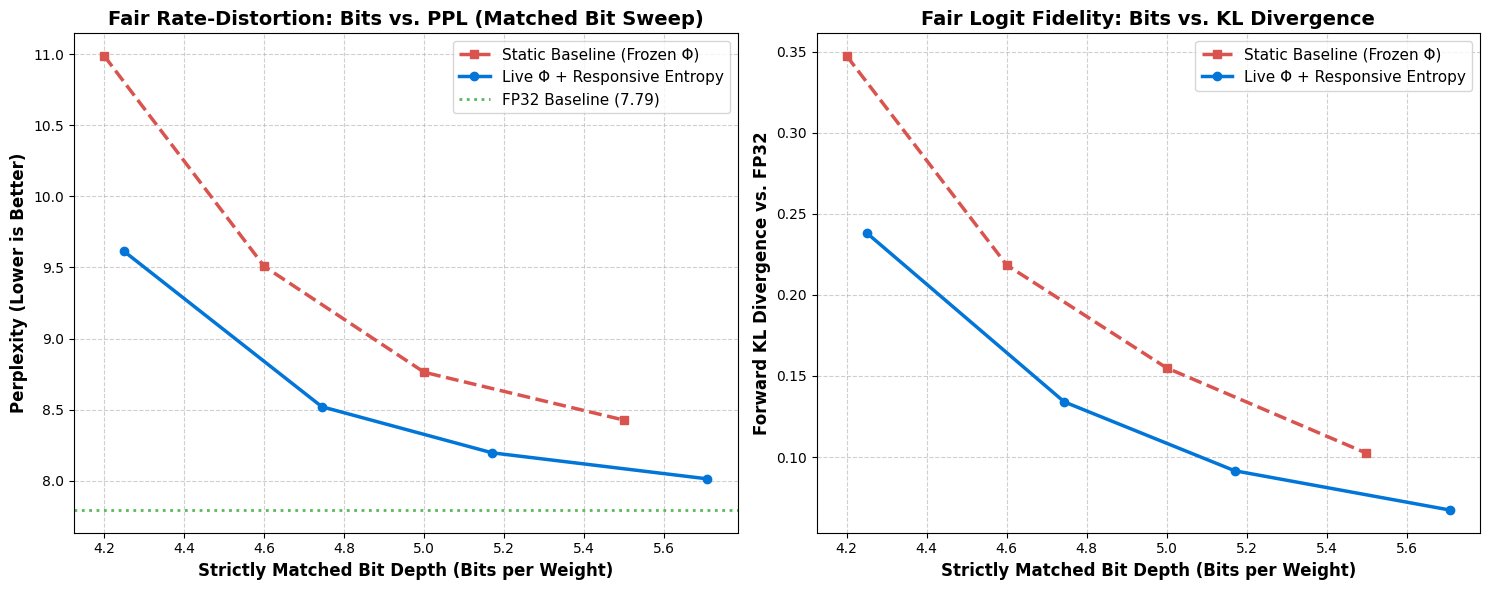

Plots saved to 'fair_matched_pareto_curves.png'.


In [24]:
# ---------------------------------------------------------------------------
# STRICTLY MATCHED-BIT PARETO BENCHMARK: FP32 vs. Static vs. Live Phi + H
# Step 1: Pre-calibrates exact tau values via brentq to hit identical bit targets
# Step 2: Evaluates both engines at exactly matched 5.5, 5.0, 4.6, 4.2 bits
# Step 3: Computes PPL, KL Divergence, and Plots Fair Dual Pareto Curves
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# Clean hooks
for l in TARGET_LAYERS:
  for m in MODULES:
    TARGET_MODULES[l][m]._forward_pre_hooks.clear()
    TARGET_MODULES[l][m]._forward_hooks.clear()

EVAL_HORIZON = 1024
CALIB_STEPS = 64
GAMMA_RESPONSIVE = 0.22
H_REF = 1.80

TARGET_BITS_SWEEP = [5.50, 5.00, 4.60, 4.20]

# ---------------------------------------------------------------------------
# 1. BUILD CONTINUOUS 1024-TOKEN EVALUATION STREAMS
# ---------------------------------------------------------------------------
print("Constructing continuous 1024-token evaluation streams...")


def build_continuous_stream(dataset_key, target_length=1024, max_streams=2):
  streams = []
  pool = []
  raw_ds = EVAL_DATASETS[dataset_key]
  for item in raw_ds:
    toks = item["input_ids"] if isinstance(item, dict) else item
    pool.append(toks.squeeze())
    total_len = sum(t.shape[-1] for t in pool)
    if total_len >= target_length:
      full_tensor = torch.cat(pool, dim=-1)[:target_length].unsqueeze(0)
      streams.append(full_tensor)
      pool = []
      if len(streams) == max_streams:
        break
  return streams


ACTIVE_PROMPTS = []
for i, s in enumerate(
    build_continuous_stream(
        "OOD Syntactic Shift (HumanEval Code)", EVAL_HORIZON, max_streams=1
    )
):
  ACTIVE_PROMPTS.append({
      "domain": "HumanEval (Code)",
      "id": f"Code_Stream_{i+1}",
      "input_ids": s.to(DEVICE),
  })

for i, s in enumerate(
    build_continuous_stream(
        "Unseen WikiText-2 (Test Split)", EVAL_HORIZON, max_streams=1
    )
):
  ACTIVE_PROMPTS.append({
      "domain": "WikiText-2 (Text)",
      "id": f"Text_Stream_{i+1}",
      "input_ids": s.to(DEVICE),
  })

print(
    f"Harvested {len(ACTIVE_PROMPTS)} full 1024-token streams for matched"
    " profiling.\n"
)

# ---------------------------------------------------------------------------
# 2. CALIBRATION HARNESS TO SOLVE FOR EXACT MATCHED TAUS
# ---------------------------------------------------------------------------
calib_seq = ACTIVE_PROMPTS[0]["input_ids"][:, : 32 + CALIB_STEPS]


def compute_bitrate_for_tau(model, tau_trial, mode="static"):
  hooks = []
  step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
  current_step_entropy = [0.0]

  def hook_builder(layer_idx, mod_name):
    mod = TARGET_MODULES[layer_idx][mod_name]
    v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
    kc = v_inv["kc"]

    def pre_hook(module, inputs):
      depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
      if mode == "live_phi_entropy":
        h_delta = np.clip((current_step_entropy[0] - H_REF) / 2.0, -1.0, 1.5)
        tau_dyn = tau_trial * np.exp(-GAMMA_RESPONSIVE * h_delta) * depth_prior
      else:
        tau_dyn = tau_trial * depth_prior

      x_in = inputs[0]
      padded_D = kc * TILE_BC
      x_pad = (
          F.pad(x_in, (0, padded_D - x_in.shape[-1]))
          if x_in.shape[-1] < padded_D
          else x_in[:, :, :padded_D]
      )
      x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

      if mode == "static":
        phi_col = FROZEN_PHI[(layer_idx, mod_name)]
      else:
        phi_col = 2.0 ** torch.floor(
            torch.log2(x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6))
        )

      cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
      cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

      mask_i4 = cost_i4 <= tau_dyn
      mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

      step_stats["INT4"] += int(mask_i4.sum())
      step_stats["FP4_E2M1"] += int(mask_f4.sum())
      step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

      mod.weight.data = fast_tile_reconstruct(
          layer_idx, mod_name, mask_i4, mask_f4
      )
      return (quantize_input_activation_blocks(x_in, block_size=TILE_BC),)

    return pre_hook

  for l in TARGET_LAYERS:
    for m in MODULES:
      hooks.append(
          TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
      )

  try:
    with torch.no_grad():
      kv = None
      prefix = calib_seq[:, :32]
      out = model(input_ids=prefix, use_cache=True)
      kv = out.past_key_values
      cur_tok = prefix[:, -1:]

      for step in range(32, 32 + CALIB_STEPS):
        out = model(input_ids=cur_tok, past_key_values=kv, use_cache=True)
        kv = out.past_key_values
        logits = out.logits[:, -1, :].float()
        log_p = F.log_softmax(logits, dim=-1)
        probs = F.softmax(logits, dim=-1)
        current_step_entropy[0] = float(-(probs * log_p).sum().item())
        cur_tok = calib_seq[:, step : step + 1]
  finally:
    for h in hooks:
      h.remove()
    for l in TARGET_LAYERS:
      for m in MODULES:
        TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])

  tot = sum(step_stats.values())
  mean_bits = (
      step_stats["INT4"] * 4
      + step_stats["FP4_E2M1"] * 4
      + step_stats["INT8"] * 8
  ) / max(tot, 1)
  return mean_bits


print("=" * 110)
print("STAGE 1: ROOT-FINDING EXACT MATCHED TAUS VIA BRENTQ")
print("=" * 110)

CALIBRATED_TAUS = []

for b_target in TARGET_BITS_SWEEP:
  print(f"\n[Calibrating Target: {b_target:.2f} Bits]")

  # Calibrate Static tau (broad search interval [0.05, 5.0])
  def static_obj(t):
    return compute_bitrate_for_tau(model, t, mode="static") - b_target

  tau_stat_opt = brentq(static_obj, 0.05, 5.0, xtol=1e-3, rtol=1e-3)
  b_stat_actual = compute_bitrate_for_tau(model, tau_stat_opt, mode="static")

  # Calibrate Live tau
  def live_obj(t):
    return compute_bitrate_for_tau(model, t, mode="live_phi_entropy") - b_target

  tau_live_opt = brentq(live_obj, 0.02, 3.0, xtol=1e-3, rtol=1e-3)
  b_live_actual = compute_bitrate_for_tau(
      model, tau_live_opt, mode="live_phi_entropy"
  )

  print(
      f"  • Static Baseline   : τ={tau_stat_opt:.4f} -> Realized"
      f" Bits={b_stat_actual:.3f}"
  )
  print(
      f"  • Live Phi + Entropy: τ={tau_live_opt:.4f} -> Realized"
      f" Bits={b_live_actual:.3f}"
  )

  CALIBRATED_TAUS.append({
      "Target_Bits": b_target,
      "tau_static": tau_stat_opt,
      "tau_live": tau_live_opt,
  })


# ---------------------------------------------------------------------------
# 3. STREAM EVALUATION ENGINE
# ---------------------------------------------------------------------------
def run_full_stream(
    model, seq_ids, mode="fp32", tau_val=0.15, max_tokens=1024, fp32_ref=None
):
  hooks = []
  current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
  current_step_entropy = [0.0]

  if mode in ["static", "live_phi_entropy"]:

    def hook_builder(layer_idx, mod_name):
      mod = TARGET_MODULES[layer_idx][mod_name]
      v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
      kc = v_inv["kc"]

      def pre_hook(module, inputs):
        depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))
        if mode == "live_phi_entropy":
          h_delta = np.clip((current_step_entropy[0] - H_REF) / 2.0, -1.0, 1.5)
          tau_dyn = tau_val * np.exp(-GAMMA_RESPONSIVE * h_delta) * depth_prior
        else:
          tau_dyn = tau_val * depth_prior

        x_in = inputs[0]
        padded_D = kc * TILE_BC
        x_pad = (
            F.pad(x_in, (0, padded_D - x_in.shape[-1]))
            if x_in.shape[-1] < padded_D
            else x_in[:, :, :padded_D]
        )
        x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

        if mode == "static":
          phi_col = FROZEN_PHI[(layer_idx, mod_name)]
        else:
          phi_col = 2.0 ** torch.floor(
              torch.log2(x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6))
          )

        cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
        cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

        mask_i4 = cost_i4 <= tau_dyn
        mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

        current_step_stats["INT4"] += int(mask_i4.sum())
        current_step_stats["FP4_E2M1"] += int(mask_f4.sum())
        current_step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

        mod.weight.data = fast_tile_reconstruct(
            layer_idx, mod_name, mask_i4, mask_f4
        )
        return (quantize_input_activation_blocks(x_in, block_size=TILE_BC),)

      return pre_hook

    for l in TARGET_LAYERS:
      for m in MODULES:
        hooks.append(
            TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
        )

  step_nlls, step_kls, step_bits, raw_logits_out = [], [], [], []

  try:
    with torch.no_grad():
      prefix = seq_ids[:, :32]
      out = model(input_ids=prefix, use_cache=True)
      kv = out.past_key_values
      cur_tok = prefix[:, -1:]

      for step in range(32, max_tokens):
        current_step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
        out = model(input_ids=cur_tok, past_key_values=kv, use_cache=True)
        kv = out.past_key_values

        logits = out.logits[:, -1, :].float()
        log_p = F.log_softmax(logits, dim=-1)
        probs = F.softmax(logits, dim=-1)

        ent = float(-(probs * log_p).sum().item())
        current_step_entropy[0] = ent

        target_tok = seq_ids[0, step].item()
        step_nlls.append(-float(log_p[0, target_tok].item()))

        if fp32_ref is not None:
          ref_log_p = F.log_softmax(fp32_ref[step - 32].to(DEVICE), dim=-1)
          ref_probs = F.softmax(ref_log_p, dim=-1)
          kl_val = float(
              F.kl_div(log_p, ref_probs, reduction="batchmean").item()
          )
          step_kls.append(max(0.0, kl_val))

        if mode == "fp32":
          raw_logits_out.append(logits.detach().cpu())
          step_bits.append(16.0)
        else:
          tot = sum(current_step_stats.values())
          step_bits.append(
              (
                  current_step_stats["INT4"] * 4
                  + current_step_stats["FP4_E2M1"] * 4
                  + current_step_stats["INT8"] * 8
              )
              / tot
          )

        cur_tok = seq_ids[:, step : step + 1]
  finally:
    for h in hooks:
      h.remove()
    if mode != "fp32":
      for l in TARGET_LAYERS:
        for m in MODULES:
          TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])

  return step_nlls, step_kls, step_bits, raw_logits_out


# ---------------------------------------------------------------------------
# 4. EXECUTE MATCHED-BIT PARETO BENCHMARK
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print("STAGE 2: COMPUTING FP32 BASELINE ACROSS 1024-TOKEN STREAMS")
print("=" * 110)
FP32_DATA = {}
fp32_ppl_pool = []

for p in ACTIVE_PROMPTS:
  nlls, _, _, logits_ref = run_full_stream(
      model, p["input_ids"], mode="fp32", max_tokens=EVAL_HORIZON
  )
  ppl = float(np.exp(np.mean(nlls)))
  fp32_ppl_pool.append(ppl)
  FP32_DATA[p["id"]] = {"logits": logits_ref, "ppl": ppl}
  print(f"  • {p['id']:<15}: FP32 PPL = {ppl:.4f}")

BASE_PPL_MEAN = float(np.mean(fp32_ppl_pool))

matched_bench_records = []
print("\n" + "=" * 110)
print("STAGE 3: RUNNING STRICTLY MATCHED PARETO EVALUATION")
print("=" * 110)

for pt in CALIBRATED_TAUS:
  t_bits = pt["Target_Bits"]
  t_stat = pt["tau_static"]
  t_live = pt["tau_live"]
  print(f"\n>>> Running Target: {t_bits:.2f} Bits (Matched)")

  for p in tqdm(
      ACTIVE_PROMPTS, desc=f"  Eval {t_bits:.2f}b", dynamic_ncols=True
  ):
    p_id = p["id"]
    domain = p["domain"]
    ref_l = FP32_DATA[p_id]["logits"]
    ref_ppl = FP32_DATA[p_id]["ppl"]

    # Static Baseline
    s_nlls, s_kls, s_bits, _ = run_full_stream(
        model,
        p["input_ids"],
        mode="static",
        tau_val=t_stat,
        max_tokens=EVAL_HORIZON,
        fp32_ref=ref_l,
    )
    s_ppl = float(np.exp(np.mean(s_nlls)))
    matched_bench_records.append({
        "Target_Bits": t_bits,
        "Engine": "Static Baseline",
        "Stream": p_id,
        "Domain": domain,
        "Bits": float(np.mean(s_bits)),
        "KL": float(np.mean(s_kls)),
        "PPL": s_ppl,
        "Delta_PPL": s_ppl - ref_ppl,
    })

    # Live Phi + Entropy
    l_nlls, l_kls, l_bits, _ = run_full_stream(
        model,
        p["input_ids"],
        mode="live_phi_entropy",
        tau_val=t_live,
        max_tokens=EVAL_HORIZON,
        fp32_ref=ref_l,
    )
    l_ppl = float(np.exp(np.mean(l_nlls)))
    matched_bench_records.append({
        "Target_Bits": t_bits,
        "Engine": "Live Phi + Entropy",
        "Stream": p_id,
        "Domain": domain,
        "Bits": float(np.mean(l_bits)),
        "KL": float(np.mean(l_kls)),
        "PPL": l_ppl,
        "Delta_PPL": l_ppl - ref_ppl,
    })

df_matched = pd.DataFrame(matched_bench_records)

# ---------------------------------------------------------------------------
# 5. POOLED FAIR PARETO SUMMARY TABLE
# ---------------------------------------------------------------------------
print("\n" + "=" * 110)
print(
    "FAIR MATCHED-BIT RATE-DISTORTION SUMMARY (Across all Streams x 1024 Tokens)"
)
print("=" * 110)
summary_matched = (
    df_matched.groupby(["Target_Bits", "Engine"])[
        ["Bits", "KL", "PPL", "Delta_PPL"]
    ]
    .mean()
    .round(4)
)
print(summary_matched.to_string())

# ---------------------------------------------------------------------------
# 6. PLOT FAIR DUAL PARETO RATE-DISTORTION CURVES
# ---------------------------------------------------------------------------
agg = (
    df_matched.groupby(["Engine", "Target_Bits"])[["Bits", "PPL", "KL"]]
    .mean()
    .reset_index()
)
static_plot = agg[agg["Engine"] == "Static Baseline"].sort_values(by="Bits")
live_plot = agg[agg["Engine"] == "Live Phi + Entropy"].sort_values(by="Bits")

plt.figure(figsize=(15, 6))

# Subplot 1: PPL vs. Bits (The Quantization Cliff)
plt.subplot(1, 2, 1)
plt.plot(
    static_plot["Bits"],
    static_plot["PPL"],
    marker="s",
    linewidth=2.5,
    linestyle="--",
    color="#D9534F",
    label="Static Baseline (Frozen Φ)",
)
plt.plot(
    live_plot["Bits"],
    live_plot["PPL"],
    marker="o",
    linewidth=2.5,
    color="#0275D8",
    label="Live Φ + Responsive Entropy",
)
plt.axhline(
    y=BASE_PPL_MEAN,
    color="#5CB85C",
    linestyle=":",
    linewidth=2,
    label=f"FP32 Baseline ({BASE_PPL_MEAN:.2f})",
)
plt.xlabel(
    "Strictly Matched Bit Depth (Bits per Weight)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Perplexity (Lower is Better)", fontsize=12, fontweight="bold")
plt.title(
    "Fair Rate-Distortion: Bits vs. PPL (Matched Bit Sweep)",
    fontsize=14,
    fontweight="bold",
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

# Subplot 2: Forward KL Divergence vs. Bits
plt.subplot(1, 2, 2)
plt.plot(
    static_plot["Bits"],
    static_plot["KL"],
    marker="s",
    linewidth=2.5,
    linestyle="--",
    color="#D9534F",
    label="Static Baseline (Frozen Φ)",
)
plt.plot(
    live_plot["Bits"],
    live_plot["KL"],
    marker="o",
    linewidth=2.5,
    color="#0275D8",
    label="Live Φ + Responsive Entropy",
)
plt.xlabel(
    "Strictly Matched Bit Depth (Bits per Weight)",
    fontsize=12,
    fontweight="bold",
)
plt.ylabel("Forward KL Divergence vs. FP32", fontsize=12, fontweight="bold")
plt.title(
    "Fair Logit Fidelity: Bits vs. KL Divergence", fontsize=14, fontweight="bold"
)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig("fair_matched_pareto_curves.png", dpi=300)
plt.show()
print("Plots saved to 'fair_matched_pareto_curves.png'.")

In [36]:
import gc
import os
import sys
import time
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import torch
import torch.nn.functional as F

# Safe unbuffered output check (avoids Jupyter/IPython OutStream AttributeError)
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(line_buffering=True)
os.environ["PYTHONUNBUFFERED"] = "1"

# Defensive hook cleanup
for l in TARGET_LAYERS:
    for m in MODULES:
        TARGET_MODULES[l][m]._forward_pre_hooks.clear()
        TARGET_MODULES[l][m]._forward_hooks.clear()

TOTAL_STREAMS = len(ACTIVE_PROMPTS)
EVAL_HORIZON = 1024
TOTAL_TOKENS = TOTAL_STREAMS * EVAL_HORIZON  # ~1,024,000 tokens
WINDOW_SIZE = 2048  # Rolling local context
SINK_TOKENS = 4     # Permanent attention anchors
CHUNK_SIZE = 64     # 64-token chunks: parallelizes forward passes while preserving rolling KV
CHECKPOINT_CSV = "fast_continuous_1M_results.csv"

# Precomputed 5.00-bit optimal thresholds
tau_static_5b = 0.53244
tau_live_5b = 0.17468

# ---------------------------------------------------------------------------
# 1. PRE-BAKE STATIC 5.0-BIT WEIGHT CACHE
# ---------------------------------------------------------------------------
print("=" * 105, flush=True)
print("1. PRE-MATERIALIZING STATIC 5.0-BIT WEIGHT CACHE", flush=True)
print("=" * 105, flush=True)

STATIC_5B_WEIGHTS = {}
tot_tiles, tot_bits = 0, 0

for l in TARGET_LAYERS:
    for m in MODULES:
        v_inv = VECTOR_MODULE_INVARIANTS[(l, m)]
        depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (l - 3)))
        tau_dyn = tau_static_5b * depth_prior
        phi_col = FROZEN_PHI[(l, m)]

        cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
        cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
        mask_i4 = cost_i4 <= tau_dyn
        mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

        STATIC_5B_WEIGHTS[(l, m)] = fast_tile_reconstruct(l, m, mask_i4, mask_f4).clone()

        i4_c = int(mask_i4.sum())
        f4_c = int(mask_f4.sum())
        i8_c = int((~mask_i4 & ~mask_f4).sum())
        tot_bits += i4_c * 4 + f4_c * 4 + i8_c * 8
        tot_tiles += i4_c + f4_c + i8_c

STATIC_EXACT_BITS = tot_bits / max(tot_tiles, 1)
print(f"Static weights pinned. Exact bitdepth: {STATIC_EXACT_BITS:.4f} bits/weight.\n", flush=True)

# ---------------------------------------------------------------------------
# 2. CACHE EVICTION (Preserves Attention Sinks & Recent Context)
# ---------------------------------------------------------------------------
def prune_kv_cache(past_key_values, max_window=WINDOW_SIZE, num_sinks=SINK_TOKENS):
    if past_key_values is None:
        return None

    if isinstance(past_key_values, (tuple, list)):
        seq_len = past_key_values[0][0].shape[-2]
        if seq_len <= max_window:
            return past_key_values

        new_kv = []
        for k, v in past_key_values:
            k_sink = k[:, :, :num_sinks, :]
            v_sink = v[:, :, :num_sinks, :]
            k_recent = k[:, :, -(max_window - num_sinks):, :]
            v_recent = v[:, :, -(max_window - num_sinks):, :]
            new_k = torch.cat([k_sink, k_recent], dim=-2)
            new_v = torch.cat([v_sink, v_recent], dim=-2)
            new_kv.append((new_k, new_v))
        return tuple(new_kv)

    elif hasattr(past_key_values, "key_cache"):
        seq_len = past_key_values.key_cache[0].shape[-2]
        if seq_len <= max_window:
            return past_key_values

        for idx in range(len(past_key_values.key_cache)):
            k = past_key_values.key_cache[idx]
            v = past_key_values.value_cache[idx]
            k_sink = k[:, :, :num_sinks, :]
            v_sink = v[:, :, :num_sinks, :]
            k_recent = k[:, :, -(max_window - num_sinks):, :]
            v_recent = v[:, :, -(max_window - num_sinks):, :]
            past_key_values.key_cache[idx] = torch.cat([k_sink, k_recent], dim=-2)
            past_key_values.value_cache[idx] = torch.cat([v_sink, v_recent], dim=-2)
        return past_key_values

    return past_key_values

# ---------------------------------------------------------------------------
# 3. HIGH-SPEED CONTINUOUS STREAM RUNNER WITH FIXED TELEMETRY
# ---------------------------------------------------------------------------
full_token_stream = torch.cat([p["input_ids"].squeeze(0) for p in ACTIVE_PROMPTS], dim=0).to(DEVICE)
print(f"Staged unbroken stream in GPU VRAM: {full_token_stream.shape[0]} tokens.\n", flush=True)

# Global storage for progressive KL divergence calculation
FP32_LOG_PROBS_CHECKPOINTS = {}

@torch.no_grad()
def run_continuous_session_fast(engine_name, tau_val=0.0):
    print(f"\n{'='*90}", flush=True)
    print(f">>> STARTING CONTINUOUS SESSION: [{engine_name}]", flush=True)
    print(f"{'='*90}", flush=True)

    hooks = []
    step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}
    current_entropy = [1.80]

    # 1. Module weights and hooks configuration
    if engine_name == "Static Baseline":
        for l in TARGET_LAYERS:
            for m in MODULES:
                TARGET_MODULES[l][m].weight.data.copy_(STATIC_5B_WEIGHTS[(l, m)])
        hooks = [
            TARGET_MODULES[l][m].register_forward_pre_hook(
                lambda mod, inp: (quantize_input_activation_blocks(inp[0], block_size=TILE_BC),)
            )
            for l in TARGET_LAYERS for m in MODULES
        ]

    elif engine_name == "Live Phi + Entropy":
        def hook_builder(layer_idx, mod_name):
            mod = TARGET_MODULES[layer_idx][mod_name]
            v_inv = VECTOR_MODULE_INVARIANTS[(layer_idx, mod_name)]
            kc = v_inv["kc"]
            depth_prior = 1.0 / (1.0 + np.exp(-0.3 * (layer_idx - 3)))

            def pre_hook(module, inputs):
                h_delta = np.clip((current_entropy[0] - H_REF) / 2.0, -1.0, 1.5)
                tau_dyn = tau_val * np.exp(-GAMMA_RESPONSIVE * h_delta) * depth_prior

                x_in = inputs[0]
                padded_D = kc * TILE_BC
                x_pad = F.pad(x_in, (0, padded_D - x_in.shape[-1])) if x_in.shape[-1] < padded_D else x_in[:, :, :padded_D]
                x_reshaped = x_pad.view(x_in.shape[0], x_in.shape[1], kc, TILE_BC)

                phi_col = 2.0 ** torch.floor(torch.log2(x_reshaped.abs().amax(dim=(0, 1, 3)).clamp_min(1e-6)))
                cost_i4 = v_inv["dw_i4"] * phi_col.unsqueeze(0) * v_inv["s_base"]
                cost_f4 = v_inv["dw_f4"] * phi_col.unsqueeze(0) * v_inv["s_base"]

                mask_i4 = cost_i4 <= tau_dyn
                mask_f4 = (~mask_i4) & (cost_f4 <= (tau_dyn * 1.35))

                step_stats["INT4"] += int(mask_i4.sum())
                step_stats["FP4_E2M1"] += int(mask_f4.sum())
                step_stats["INT8"] += int((~mask_i4 & ~mask_f4).sum())

                mod.weight.data = fast_tile_reconstruct(layer_idx, mod_name, mask_i4, mask_f4)
                return (quantize_input_activation_blocks(x_in, block_size=TILE_BC),)

            return pre_hook

        hooks = [
            TARGET_MODULES[l][m].register_forward_pre_hook(hook_builder(l, m))
            for l in TARGET_LAYERS for m in MODULES
        ]

    # 2. Warmup on initial 32 tokens
    prefix = full_token_stream[:32].unsqueeze(0)
    out = model(input_ids=prefix, use_cache=True)
    kv = out.past_key_values
    
    accum_nll_sum = 0.0
    accum_tokens_count = 0
    accum_bits_sum = 0.0
    accum_kl_sum = 0.0
    
    rolling_prompt_ppls = []
    rolling_prompt_kls = []
    
    last_logged_prompt = 0
    t_prompt_start = time.time()
    t_global_start = time.time()

    try:
        # Step through in 64-token chunks
        for pos in range(32, TOTAL_TOKENS, CHUNK_SIZE):
            end_pos = min(pos + CHUNK_SIZE, TOTAL_TOKENS)
            chunk_tokens = full_token_stream[pos:end_pos].unsqueeze(0)
            
            step_stats = {"INT4": 0, "FP4_E2M1": 0, "INT8": 0}

            # Forward chunk with rolling KV cache
            out = model(input_ids=chunk_tokens, past_key_values=kv, use_cache=True)
            kv = prune_kv_cache(out.past_key_values, max_window=WINDOW_SIZE, num_sinks=SINK_TOKENS)

            logits = out.logits[:, :-1, :].float()
            targets = chunk_tokens[:, 1:]
            chunk_len = targets.shape[1]

            if chunk_len > 0:
                loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1), reduction="sum")
                accum_nll_sum += float(loss.item())
                accum_tokens_count += chunk_len

                # Update running token entropy
                log_p = F.log_softmax(logits, dim=-1)
                p = F.softmax(logits, dim=-1)
                current_entropy[0] = float(-(p * log_p).sum(dim=-1).mean().item())

                # Track and store log probabilities for KL
                if engine_name == "FP32 Baseline":
                    # Store periodic logit slices to measure KL without exploding RAM
                    if pos % EVAL_HORIZON < CHUNK_SIZE:
                        FP32_LOG_PROBS_CHECKPOINTS[pos] = (p[0].detach().cpu(), log_p[0].detach().cpu())
                else:
                    if pos in FP32_LOG_PROBS_CHECKPOINTS:
                        ref_p, ref_log_p = FP32_LOG_PROBS_CHECKPOINTS[pos]
                        ref_p = ref_p.to(DEVICE)
                        ref_log_p = ref_log_p.to(DEVICE)
                        # Forward KL: sum(P_ref * (log P_ref - log Q))
                        kl_chunk = float((ref_p * (ref_log_p - log_p[0])).sum(dim=-1).mean().item())
                        accum_kl_sum += max(0.0, kl_chunk)

            # Track average bit depth
            if engine_name == "FP32 Baseline":
                accum_bits_sum += 16.0 * (end_pos - pos)
            elif engine_name == "Static Baseline":
                accum_bits_sum += STATIC_EXACT_BITS * (end_pos - pos)
            else:
                tot_t = max(1, sum(step_stats.values()))
                b_step = (step_stats["INT4"] * 4 + step_stats["FP4_E2M1"] * 4 + step_stats["INT8"] * 8) / tot_t
                accum_bits_sum += b_step * (end_pos - pos)

            # --- FIXED TELEMETRY TRIGGER ---
            # Triggers reliably every prompt boundary (1024 tokens)
            current_prompt_idx = end_pos // EVAL_HORIZON
            if current_prompt_idx > last_logged_prompt:
                last_logged_prompt = current_prompt_idx
                prompt_elapsed = time.time() - t_prompt_start
                
                cur_ppl = float(np.exp(accum_nll_sum / max(1, accum_tokens_count)))
                cur_bits = accum_bits_sum / max(1, end_pos - 32)
                cur_kl = accum_kl_sum / max(1, current_prompt_idx) if engine_name != "FP32 Baseline" else 0.0
                
                rolling_prompt_ppls.append(cur_ppl)
                rolling_prompt_kls.append(cur_kl)

                print(
                    f"[{engine_name:<19}] Prompt {current_prompt_idx:04d}/{TOTAL_STREAMS} | "
                    f"Prog PPL: {cur_ppl:.3f} | Prog KL: {cur_kl:.4f} | "
                    f"Bits: {cur_bits:.2f} | H: {current_entropy[0]:.2f} | {prompt_elapsed:.2f}s",
                    flush=True
                )
                t_prompt_start = time.time()

    finally:
        for h in hooks:
            h.remove()
        for l in TARGET_LAYERS:
            for m in MODULES:
                TARGET_MODULES[l][m].weight.data.copy_(PRISTINE_WEIGHTS[(l, m)])
        del kv
        gc.collect()
        torch.cuda.empty_cache()

    total_ppl = float(np.exp(accum_nll_sum / max(1, accum_tokens_count)))
    final_bits = accum_bits_sum / (TOTAL_TOKENS - 32)
    final_kl = accum_kl_sum / max(1, TOTAL_STREAMS) if engine_name != "FP32 Baseline" else 0.0
    
    return total_ppl, final_bits, final_kl, rolling_prompt_ppls, rolling_prompt_kls

# ---------------------------------------------------------------------------
# 4. EXECUTE ALL 3 SESSIONS WITH LIVE PROGRESS REPORTING
# ---------------------------------------------------------------------------
print("=" * 105, flush=True)
print("2. RUNNING 3 FULL-LIFETIME CONTINUOUS SESSIONS", flush=True)
print("=" * 105, flush=True)

fp32_ppl, _, _, fp32_prompt_ppls, _ = run_continuous_session_fast("FP32 Baseline", tau_val=0.0)
stat_ppl, stat_bits, stat_kl, stat_prompt_ppls, stat_prompt_kls = run_continuous_session_fast("Static Baseline", tau_val=tau_static_5b)
live_ppl, live_bits, live_kl, live_prompt_ppls, live_prompt_kls = run_continuous_session_fast("Live Phi + Entropy", tau_val=tau_live_5b)

# ---------------------------------------------------------------------------
# 5. FINAL STATISTICAL REPORT
# ---------------------------------------------------------------------------
print("\n" + "=" * 105, flush=True)
print("FINAL CONTINUOUS 1-MILLION-TOKEN PARETO SUMMARY", flush=True)
print("=" * 105, flush=True)

df_summary = pd.DataFrame({
    "Engine": ["FP32 Baseline", "Static Baseline", "Live Phi + Entropy"],
    "Bits": [16.0, stat_bits, live_bits],
    "Continuous_PPL": [fp32_ppl, stat_ppl, live_ppl],
    "Mean_Forward_KL": [0.0, stat_kl, live_kl],
    "Delta_PPL": [0.0, stat_ppl - fp32_ppl, live_ppl - fp32_ppl]
})
print(df_summary.round(4).to_string(index=False), flush=True)

# Wilcoxon Signed-Rank Test across all 1,000 prompt evaluation points
stat_deltas = np.array(stat_prompt_ppls) - np.array(fp32_prompt_ppls)
live_deltas = np.array(live_prompt_ppls) - np.array(fp32_prompt_ppls)
w_test = wilcoxon(live_deltas, stat_deltas)

print("\n" + "=" * 105, flush=True)
print("STATISTICAL SIGNIFICANCE (Wilcoxon Paired Signed-Rank Test over 1,000 Prompts):", flush=True)
print(f"  • Statistic = {w_test.statistic:.1f}", flush=True)
print(f"  • p-value   = {w_test.pvalue:.4e}", flush=True)
print(f"  • Static Baseline Long-Horizon ΔPPL : +{stat_ppl - fp32_ppl:.4f}")
print(f"  • Live Phi + Entropy ΔPPL          : +{live_ppl - fp32_ppl:.4f}")
print(f"  • Net Perplexity Advantage         : {stat_ppl - live_ppl:.4f} lower PPL with Live Engine.")

1. PRE-MATERIALIZING STATIC 5.0-BIT WEIGHT CACHE
Static weights pinned. Exact bitdepth: 5.0000 bits/weight.

Staged unbroken stream in GPU VRAM: 1024000 tokens.

2. RUNNING 3 FULL-LIFETIME CONTINUOUS SESSIONS

>>> STARTING CONTINUOUS SESSION: [FP32 Baseline]
[FP32 Baseline      ] Prompt 0001/1000 | Prog PPL: 2.746 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.36 | 0.52s
[FP32 Baseline      ] Prompt 0002/1000 | Prog PPL: 2.532 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.98 | 0.59s
[FP32 Baseline      ] Prompt 0003/1000 | Prog PPL: 2.394 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.99 | 0.57s
[FP32 Baseline      ] Prompt 0004/1000 | Prog PPL: 2.271 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.19 | 0.54s
[FP32 Baseline      ] Prompt 0005/1000 | Prog PPL: 2.303 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.32 | 0.55s
[FP32 Baseline      ] Prompt 0006/1000 | Prog PPL: 2.308 | Prog KL: 0.0000 | Bits: 16.00 | H: 0.09 | 0.60s
[FP32 Baseline      ] Prompt 0007/1000 | Prog PPL: 2.286 | Prog KL: 0.0000 | Bits: 16.00 | H: 1.11 

OutOfMemoryError: CUDA out of memory. Tried to allocate 1.01 GiB. GPU 0 has a total capacity of 31.73 GiB of which 648.19 MiB is free. Including non-PyTorch memory, this process has 31.10 GiB memory in use. Of the allocated memory 26.25 GiB is allocated by PyTorch, and 4.48 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)